# Nestlé WISER DOM experiment notebook

This notebook is self-contained: use **Run All** after editing the global configuration
cell directly below the dependency bootstrap. Missing local notebook dependencies are
installed by the kernel. It reads the five canonical runtime CSV inputs and, when present, two optional
recommendation-output CSVs. Only aggregate metrics and figures are saved.

Notebook evidence is stored in the directory
`results/challenge-study/notebook/<profile>/`. Start with `PROFILE = "smoke"`; change
it to `"full"` for final evidence. Verified per-experiment checkpoints let a long run
resume without creating nested problem/run hash directories.


In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path


def _project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "pyproject.toml").is_file() and (candidate / "src/domopt").is_dir():
            return candidate
    raise RuntimeError(
        "Open this notebook from inside the wiser-dom-optimization repository"
    )


PROJECT_ROOT = _project_root(Path.cwd())
source_directory = str(PROJECT_ROOT / "src")
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)

required_modules = ("numpy", "pandas", "scipy", "yaml", "matplotlib", "nbformat")
missing_modules = [
    module for module in required_modules if importlib.util.find_spec(module) is None
]
if missing_modules:
    print(f"Installing missing notebook dependencies: {', '.join(missing_modules)}")
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--disable-pip-version-check",
            "-e",
            f"{PROJECT_ROOT}[notebook]",
        ],
        check=True,
    )
print(f"Notebook environment ready: {PROJECT_ROOT}")


Notebook environment ready: /mnt/Home/apomorov/Wiser/wiser-dom-optimization


In [2]:
from __future__ import annotations

from dataclasses import asdict, replace
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from domopt.checkpoints import (
    StaleCheckpointError,
    challenge_results_root,
    checkpoint_identity,
    checkpoint_run_directory,
    load_checkpoint,
    write_checkpoint,
)
from domopt.experiments import (
    experiment_profile,
    ibm_hardware_study_logical_qubits,
    make_ibm_hardware_study_problem,
    rank_ibm_hardware_strategies,
    run_challenge_experiments,
    run_ibm_hardware_study,
    write_experiment_results,
)
from domopt.hardware import (
    benchmark_qubo_batch_scoring,
    discover_ibm_backends,
    hardware_capabilities,
)
from domopt.poc import (
    POC_REFERENCE_FILENAMES,
    PocConfig,
    audit_poc_bundle,
    audit_poc_outputs,
    load_poc_problem,
    prune_pareto_candidates,
)
from domopt.visualization import (
    plot_challenge_results,
    plot_hardware_benchmark,
    plot_ibm_backend_snapshot,
    plot_ibm_hardware_study,
)


def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (
            (candidate / "pyproject.toml").is_file()
            and (candidate / "src/domopt").is_dir()
        ):
            return candidate
    raise RuntimeError(
        "Run this notebook from inside the wiser-dom-optimization repository"
    )


# -----------------------------------------------------------------------------
# GLOBAL CONFIGURATION — edit only this block, then use Run All.
# -----------------------------------------------------------------------------
PROJECT_ROOT = find_project_root(Path.cwd())
BUNDLE_DIR = (PROJECT_ROOT / "data/raw/nestle_challenge").resolve()
PROFILE = "full"  # "smoke" for a quick check; "full" for final evidence
FORCE_RERUN = False
POC_SETTINGS = PocConfig(
    protection_days=5,
    min_divert_improvement_fraction=0.05,
    min_divert_improvement_cases=100,
    candidate_dc_scope="network_intersection",
    pareto_prune=False,
)
# Override any profile field without editing package code. Examples:
# PROFILE_OVERRIDES = {"sizes": (8, 20, 50), "scaling_repetitions": 2}
# HYBRID_OVERRIDES = {"max_candidates_per_order": 2, "num_reads": 64}
# EXACT_LNS_OVERRIDES = {"iterations": 3, "local_time_limit_seconds": 10}
PROFILE_OVERRIDES: dict[str, object] = {}
HYBRID_OVERRIDES: dict[str, object] = {}
EXACT_LNS_OVERRIDES: dict[str, object] = {}
ENABLED_EXPERIMENTS = {
    "solver_comparison": True,
    "size_scaling": True,
    "synthetic_scaling": True,
    "candidate_dc_scope_sensitivity": True,
    "penalty_weight_sensitivity": True,
    "qubo_penalty_sensitivity": True,
    "candidate_count_sensitivity": True,
    "inventory_shock": True,
    "qubo_coefficient_noise": True,
    "qaoa_readout_noise": True,
    "pareto_pruning_ablation": True,
    "batch_strategy_ablation": True,
    "sampler_ablation": True,
    "synthetic_coordination_control": True,
}
ENABLE_GPU_BENCHMARK = True
ENABLE_IBM_HARDWARE = True  # True submits synthetic-only circuits to IBM Quantum
IBM_HARDWARE_PROFILE = "presentation"  # "quick" = 6 jobs; "presentation" = 18
IBM_SHOTS = 512
IBM_BACKEND_NAME = None  # None selects the least-busy eligible backend
OUTPUT_ROOT = challenge_results_root(PROJECT_ROOT, producer="notebook")

print(
    {
        "project_root": str(PROJECT_ROOT),
        "bundle_dir": str(BUNDLE_DIR),
        "profile": PROFILE,
        "force_rerun": FORCE_RERUN,
        "enabled_experiments": sum(ENABLED_EXPERIMENTS.values()),
        "notebook_results_root": str(OUTPUT_ROOT),
        "ibm_hardware_enabled": ENABLE_IBM_HARDWARE,
        "ibm_hardware_profile": IBM_HARDWARE_PROFILE,
        "requested_ibm_backend": IBM_BACKEND_NAME or "least_busy",
    }
)


{'project_root': '/mnt/Home/apomorov/Wiser/wiser-dom-optimization', 'bundle_dir': '/mnt/Home/apomorov/Wiser/wiser-dom-optimization/data/raw/nestle_challenge', 'profile': 'full', 'force_rerun': False, 'enabled_experiments': 14, 'notebook_results_root': '/mnt/Home/apomorov/Wiser/wiser-dom-optimization/results/challenge-study/notebook', 'ibm_hardware_enabled': True, 'ibm_hardware_profile': 'presentation', 'requested_ibm_backend': 'least_busy'}


## 1. Runtime-input readability gate

**Purpose.** Verify that the five required runtime tables are present, readable, and
non-empty before any modeling work begins. Two recommendation outputs are optional audits.

**Why it matters.** A solver result is not reproducible when an upload is missing, a
numbered duplicate is selected accidentally, or a metadata sidecar is read as data.
Use `scripts/prepare_challenge_bundle.py` once if downloaded filenames need cleanup.


In [3]:
file_audit = audit_poc_bundle(BUNDLE_DIR)
assert file_audit["readable"].all()
display(
    file_audit[
        ["role", "filename", "rows", "columns", "readable"]
    ]
)


,role,filename,rows,columns,readable
0,inventory,input_capacity_planning.csv,377504,23,True
1,orders,input_order_data.csv,25193,39,True
2,shipping,input_shipping_cost_data.csv,12922,7,True
3,dock,input_dock_capacity.csv,480,13,True
4,throughput,input_throughput_capacity.csv,530,7,True


## 2. Build and audit the real POC model

**Purpose.** Convert planning units to integer cases, identify focus loads, create
eligible DC/date options, protect five days of inventory, and apply documented dock
and penalty rules. Pareto pruning remains disabled here so it can be tested later.

**Why it matters.** This gate proves the optimization instance has the intended grain,
keys, candidate universe, and resource accounting before comparing algorithms.


In [4]:
problem_unpruned = load_poc_problem(
    BUNDLE_DIR,
    config=POC_SETTINGS,
    strict_bundle_audit=False,
)
problem_pruned = prune_pareto_candidates(problem_unpruned)
summary = pd.DataFrame(
    [
        {
            "variant": "unpruned",
            "orders": len(problem_unpruned.orders),
            "assignment_groups": problem_unpruned.orders[
                "assignment_group"
            ].nunique(),
            "order_lines": len(problem_unpruned.order_lines),
            "candidate_rows": len(problem_unpruned.candidates),
        },
        {
            "variant": "pareto_pruned",
            "orders": len(problem_pruned.orders),
            "assignment_groups": problem_pruned.orders[
                "assignment_group"
            ].nunique(),
            "order_lines": len(problem_pruned.order_lines),
            "candidate_rows": len(problem_pruned.candidates),
        },
    ]
)
display(summary)

reference_available = all(
    (BUNDLE_DIR / name).is_file()
    for name in POC_REFERENCE_FILENAMES.values()
)
if reference_available:
    display(
        pd.Series(
            audit_poc_outputs(BUNDLE_DIR, problem_unpruned),
            name="reference audit",
        )
    )
else:
    print(
        "Optional recommendation outputs are absent; "
        "reconciliation is skipped."
    )


,variant,orders,assignment_groups,order_lines,candidate_rows
0,unpruned,750,372,20869,2182
1,pareto_pruned,750,372,20869,1307


orders                               1109
order_sku_rows                      25193
named_loads                           614
assignment_groups                     631
diverted_orders                         3
order_sku_key_coverage               True
requested_cases                   2554440
selected_fulfilled_cases          2413937
selected_case_fill_rate          0.944997
default_penalty_max_abs_error         0.0
Name: reference audit, dtype: object

## 3. Verified experiment runner

**Purpose.** Run or resume each enabled study and write one easy-to-find table under
`results/challenge-study/notebook/<profile>/tables/`. Set `FORCE_RERUN = True` in the
global cell to bypass checkpoints.

**Why it matters.** Each manifest still verifies the complete configuration, problem,
source state, schema, columns, row count, and content hash, while stable profile paths
avoid opaque hash-directory proliferation. Infeasible rows are rejected before use.


In [5]:
experiment_frames: dict[str, pd.DataFrame] = {}
BASE_PROFILE = experiment_profile(PROFILE)
if {"hybrid", "exact_lns"} & set(PROFILE_OVERRIDES):
    raise ValueError(
        "Use HYBRID_OVERRIDES or EXACT_LNS_OVERRIDES for nested solver settings"
    )
PROFILE_SETTINGS = replace(
    BASE_PROFILE,
    **PROFILE_OVERRIDES,
    hybrid=replace(BASE_PROFILE.hybrid, **HYBRID_OVERRIDES),
    exact_lns=replace(BASE_PROFILE.exact_lns, **EXACT_LNS_OVERRIDES),
)
PROFILE_CONFIGURATION = {
    "experiment_profile": asdict(PROFILE_SETTINGS),
    "poc": asdict(POC_SETTINGS),
}
SUITE_IDENTITY = checkpoint_identity(
    problem_unpruned,
    profile=PROFILE,
    experiment="challenge_suite",
    configuration=PROFILE_CONFIGURATION,
)
OUTPUT_DIR = checkpoint_run_directory(OUTPUT_ROOT, SUITE_IDENTITY)
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(f"artifact scope: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")


def feasible_mask(frame: pd.DataFrame) -> pd.Series:
    values = frame["feasible"]
    if values.dtype == bool:
        return values
    return values.astype(str).str.lower().isin({"true", "1"})


def run_or_load(name: str) -> pd.DataFrame | None:
    if not ENABLED_EXPERIMENTS.get(name, False):
        print(f"skipped by global switch: {name}")
        return None
    identity = checkpoint_identity(
        problem_unpruned,
        profile=PROFILE,
        experiment=name,
        configuration=PROFILE_CONFIGURATION,
    )
    path = TABLE_DIR / f"{name}.csv"
    frame = None
    if not FORCE_RERUN:
        try:
            frame = load_checkpoint(path, identity)
            print(f"loaded verified checkpoint: {path.relative_to(PROJECT_ROOT)}")
        except StaleCheckpointError as error:
            print(f"checkpoint unavailable or stale ({error}); recomputing {name}")
    if frame is None:
        frame = run_challenge_experiments(
            problem_unpruned,
            profile=PROFILE_SETTINGS,
            experiments=[name],
        )
        write_experiment_results(frame, path)
        write_checkpoint(frame, path, identity)
        print(f"wrote verified checkpoint: {path.relative_to(PROJECT_ROOT)}")

    invalid = frame.loc[~feasible_mask(frame)]
    if not invalid.empty:
        diagnostic_columns = [
            "experiment",
            "level",
            "validation_categories",
            "validation_violation_count",
            "error_type",
        ]
        columns = [column for column in diagnostic_columns if column in invalid]
        raise RuntimeError(
            "Infeasible experiment rows: "
            f"{invalid[columns].to_dict('records')}"
        )
    experiment_frames[name] = frame
    return frame


def show_result(
    frame: pd.DataFrame | None,
    columns: list[str],
    *,
    sort_by: str | list[str] | None = None,
    ascending: bool | list[bool] = True,
) -> None:
    if frame is None:
        display(Markdown("_Skipped by the global experiment switches._"))
        return
    available = [column for column in columns if column in frame.columns]
    view = frame[available]
    if sort_by is not None:
        view = view.sort_values(sort_by, ascending=ascending)
    display(view)


artifact scope: results/challenge-study/notebook/full


## 4. Common solver comparison

**Purpose.** Compare default routing, load-atomic greedy, polished greedy, adaptive
exact-MILP LNS, full exact MILP, and sampler-assisted LNS with one objective and one
independent validator.

**Why it matters.** This is the central fairness test and determines the production
hierarchy. It separates exact quantity-polish gains from assignment-search gains and
reports normalized capture alongside source-currency totals.


In [6]:
solver_results = run_or_load("solver_comparison")
show_result(
    solver_results,
    [
        "method",
        "feasible",
        "objective_value",
        "requested_value",
        "objective_capture_rate",
        "case_fill_rate",
        "reassigned_orders",
        "penalty_cost",
        "shipping_cost",
        "runtime_seconds",
        "optimality_gap",
        "initial_polish_improvement",
        "search_improvement",
        "maximum_local_variables",
        "maximum_qubo_variables",
    ],
    sort_by="objective_value",
    ascending=False,
)


checkpoint unavailable or stale (checkpoint CSV or manifest is missing); recomputing solver_comparison
wrote verified checkpoint: results/challenge-study/notebook/full/tables/solver_comparison.csv


,method,feasible,objective_value,requested_value,objective_capture_rate,case_fill_rate,reassigned_orders,penalty_cost,shipping_cost,runtime_seconds,optimality_gap,initial_polish_improvement,search_improvement,maximum_local_variables,maximum_qubo_variables
3,exact_lns,True,1.856595e+06,2860690.0,0.649002,0.685019,4,6769.491630,22927.0,6.998784,NaN,119.443647,0.0,2951.0,NaN
2,polished_greedy,True,1.856595e+06,2860690.0,0.649002,0.685019,4,6769.491630,22927.0,2.863882,0.0,119.443647,NaN,NaN,NaN
4,classical,True,1.856595e+06,2860690.0,0.649002,0.685019,4,6769.491630,22927.0,2.761667,0.0,NaN,NaN,NaN,NaN
5,hybrid,True,1.856595e+06,2860690.0,0.649002,0.685019,4,6769.491630,22927.0,12.877778,NaN,119.443647,0.0,NaN,14.0
1,greedy,True,1.856475e+06,2860690.0,0.648961,0.685019,4,6772.970571,22927.0,0.758542,NaN,NaN,NaN,NaN,NaN
0,default,True,1.756111e+06,2860690.0,0.613877,0.642075,0,8428.067714,22834.0,0.300003,NaN,NaN,NaN,NaN,NaN


## 5. Real assignment-group size scaling

**Purpose.** Scale greedy, polished greedy, bounded exact LNS, tractable hybrid LNS,
and small-instance exact MILP over nested real assignment-group subsets.

**Why it matters.** A load can contain several orders, so assignment groups—not raw
rows—are the true decision count. Repetitions, stage runtimes, variable growth, and
normalized quality show where each method remains practical.


In [7]:
scaling_results = run_or_load("size_scaling")
show_result(
    scaling_results,
    [
        "method",
        "actual_assignment_groups",
        "repetition",
        "order_count",
        "order_line_count",
        "candidate_count",
        "maximum_local_variables",
        "maximum_qubo_variables",
        "objective_value",
        "objective_capture_rate",
        "case_fill_rate",
        "runtime_seconds",
        "feasible",
    ],
    sort_by=["actual_assignment_groups", "method", "repetition"],
)


checkpoint unavailable or stale (checkpoint CSV or manifest is missing); recomputing size_scaling
wrote verified checkpoint: results/challenge-study/notebook/full/tables/size_scaling.csv


,method,actual_assignment_groups,repetition,order_count,order_line_count,candidate_count,maximum_local_variables,maximum_qubo_variables,objective_value,objective_capture_rate,case_fill_rate,runtime_seconds,feasible
4,classical,8,1,9,129,22,NaN,NaN,3.694584e+05,0.399952,0.475581,0.228357,True
9,classical,8,2,9,129,22,NaN,NaN,3.694584e+05,0.399952,0.475581,0.229392,True
14,classical,8,3,9,129,22,NaN,NaN,3.694584e+05,0.399952,0.475581,0.227353,True
2,exact_lns,8,1,9,129,22,802.0,NaN,3.694584e+05,0.399952,0.475581,1.685273,True
7,exact_lns,8,2,9,129,22,802.0,NaN,3.694584e+05,0.399952,0.475581,1.718873,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,greedy,372,2,750,20869,2182,NaN,NaN,4.574285e+07,0.821148,0.858908,16.736931,True
66,greedy,372,3,750,20869,2182,NaN,NaN,4.574285e+07,0.821148,0.858908,16.756229,True
61,polished_greedy,372,1,750,20869,2182,NaN,NaN,4.576159e+07,0.821485,0.858907,54.733777,True
64,polished_greedy,372,2,750,20869,2182,NaN,NaN,4.576159e+07,0.821485,0.858907,54.628237,True


## 6. Controlled synthetic scaling

**Purpose.** Generate independent coupled instances at each size and compare greedy,
exact LNS, tractable hybrid LNS, and small-instance exact MILP.

**Why it matters.** Nested real subsets confound size with composition. This control
is valid for complexity and variable-growth claims, but never for real-business impact.


In [8]:
synthetic_scaling_results = run_or_load("synthetic_scaling")
show_result(
    synthetic_scaling_results,
    [
        "method",
        "actual_assignment_groups",
        "repetition",
        "generator_seed",
        "candidate_count",
        "maximum_local_variables",
        "maximum_qubo_variables",
        "objective_capture_rate",
        "runtime_seconds",
        "feasible",
    ],
    sort_by=["actual_assignment_groups", "method", "repetition"],
)


checkpoint unavailable or stale (checkpoint CSV or manifest is missing); recomputing synthetic_scaling
wrote verified checkpoint: results/challenge-study/notebook/full/tables/synthetic_scaling.csv


,method,actual_assignment_groups,repetition,generator_seed,candidate_count,maximum_local_variables,maximum_qubo_variables,objective_capture_rate,runtime_seconds,feasible
3,classical,20,1,11940,60,NaN,NaN,-0.232464,1.204117,True
7,classical,20,2,11941,60,NaN,NaN,-0.391000,0.305310,True
11,classical,20,3,11942,60,NaN,NaN,-0.663657,0.125654,True
1,exact_lns,20,1,11940,60,144.0,NaN,-0.283000,0.874599,True
5,exact_lns,20,2,11941,60,120.0,NaN,-0.431840,0.950025,True
9,exact_lns,20,3,11942,60,124.0,NaN,-0.719201,0.860232,True
0,greedy,20,1,11940,60,NaN,NaN,-0.304767,0.428052,True
4,greedy,20,2,11941,60,NaN,NaN,-0.434351,0.442399,True
8,greedy,20,3,11942,60,NaN,NaN,-0.719201,0.442250,True
2,hybrid,20,1,11940,60,NaN,27.0,-0.283000,2.703526,True


## 7. Candidate-DC universe sensitivity

**Purpose.** Compare the legacy focus/default-DC candidate universe with every DC in
the shipping, inventory, and dock-capacity intersection.

**Why it matters.** Candidate generation can silently cap solution quality. Equal
results are useful negative evidence; different results quantify that restriction.


In [9]:
candidate_scope_results = run_or_load(
    "candidate_dc_scope_sensitivity"
)
show_result(
    candidate_scope_results,
    [
        "candidate_dc_scope",
        "method",
        "candidate_count",
        "objective_capture_rate",
        "case_fill_rate",
        "runtime_seconds",
        "feasible",
    ],
    sort_by=["candidate_dc_scope", "method"],
)


checkpoint unavailable or stale (checkpoint CSV or manifest is missing); recomputing candidate_dc_scope_sensitivity
wrote verified checkpoint: results/challenge-study/notebook/full/tables/candidate_dc_scope_sensitivity.csv


,candidate_dc_scope,method,candidate_count,objective_capture_rate,case_fill_rate,runtime_seconds,feasible
1,focus_default_dcs,exact_lns,90,0.649002,0.685019,6.936661,True
0,focus_default_dcs,polished_greedy,90,0.649002,0.685019,2.893953,True
3,network_intersection,exact_lns,90,0.649002,0.685019,7.006994,True
2,network_intersection,polished_greedy,90,0.649002,0.685019,2.879673,True


## 8. Business penalty-weight sensitivity

**Purpose.** Scale unmet-demand penalties on a fixed set of loads with active penalty
exposure and compare routing, fill, penalty, and shipping outcomes.

**Why it matters.** This reveals whether recommendations are robust or driven by one
arbitrary business coefficient. Raw objectives across penalty scales are deliberately
not compared; the operational trade-offs are.


In [10]:
business_penalty_results = run_or_load(
    "penalty_weight_sensitivity"
)
show_result(
    business_penalty_results,
    [
        "penalty_scale",
        "method",
        "case_fill_rate",
        "reassigned_orders",
        "penalty_cost",
        "shipping_cost",
        "runtime_seconds",
    ],
    sort_by=["penalty_scale", "method"],
)


checkpoint unavailable or stale (checkpoint CSV or manifest is missing); recomputing penalty_weight_sensitivity
wrote verified checkpoint: results/challenge-study/notebook/full/tables/penalty_weight_sensitivity.csv


,penalty_scale,method,case_fill_rate,reassigned_orders,penalty_cost,shipping_cost,runtime_seconds
2,0.25,exact_lns,0.853182,3,12027.031546,19101.0,4.746186
0,0.25,greedy,0.853182,3,12027.054150,19101.0,0.497439
3,0.25,hybrid,0.853182,3,12027.031546,19101.0,11.799165
1,0.25,polished_greedy,0.853182,3,12027.031546,19101.0,2.185555
6,0.50,exact_lns,0.853182,3,24054.063091,19101.0,4.554433
4,0.50,greedy,0.853182,3,24054.108299,19101.0,0.498123
7,0.50,hybrid,0.853182,3,24054.063091,19101.0,11.324166
5,0.50,polished_greedy,0.853182,3,24054.063091,19101.0,2.221343
10,1.00,exact_lns,0.853182,3,48108.126182,19101.0,4.808447
8,1.00,greedy,0.853182,3,48108.216598,19101.0,0.491686


## 9. QUBO penalty calibration

**Purpose.** Sweep one-hot and shared-resource QUBO penalty multipliers while measuring
raw validity, repair burden, validated improvement, and runtime.

**Why it matters.** These are algorithmic penalties—not business costs—and poor values
can dominate the proposal energy. Calibration prevents an arbitrary encoding choice.


In [11]:
qubo_penalty_results = run_or_load("qubo_penalty_sensitivity")
show_result(
    qubo_penalty_results,
    [
        "one_hot_penalty_multiplier",
        "pair_penalty_multiplier",
        "raw_one_hot_rate",
        "hybrid_improvement",
        "accepted_moves",
        "recourse_solves",
        "runtime_seconds",
    ],
    sort_by=["one_hot_penalty_multiplier", "pair_penalty_multiplier"],
)


checkpoint unavailable or stale (checkpoint CSV or manifest is missing); recomputing qubo_penalty_sensitivity
wrote verified checkpoint: results/challenge-study/notebook/full/tables/qubo_penalty_sensitivity.csv


,one_hot_penalty_multiplier,pair_penalty_multiplier,raw_one_hot_rate,hybrid_improvement,accepted_moves,recourse_solves,runtime_seconds
0,1.05,0.0,0.989583,197.2,1,3,3.190499
1,1.05,0.5,1.000000,197.2,1,9,3.328190
2,1.05,1.0,1.000000,197.2,1,12,3.406862
3,1.05,2.0,1.000000,197.2,1,18,3.524511
4,1.25,0.0,0.994792,197.2,1,3,3.171575
5,1.25,0.5,1.000000,197.2,1,9,3.346788
6,1.25,1.0,1.000000,197.2,1,12,3.411298
7,1.25,2.0,1.000000,197.2,1,18,3.599504
8,1.50,0.0,0.997396,197.2,1,3,3.022402
9,1.50,0.5,1.000000,197.2,1,9,3.273823


## 10. Candidate-count sensitivity

**Purpose.** Vary the retained DC/date alternatives per assignment group and measure
quality, QUBO width, and runtime.

**Why it matters.** Candidate caps are the main scalability lever. This identifies the
point where extra alternatives stop paying for their computational cost.


In [12]:
candidate_results = run_or_load("candidate_count_sensitivity")
show_result(
    candidate_results,
    [
        "candidate_limit",
        "method",
        "candidate_count",
        "maximum_qubo_variables",
        "objective_value",
        "case_fill_rate",
        "runtime_seconds",
    ],
    sort_by=["candidate_limit", "method"],
)


checkpoint unavailable or stale (checkpoint CSV or manifest is missing); recomputing candidate_count_sensitivity
wrote verified checkpoint: results/challenge-study/notebook/full/tables/candidate_count_sensitivity.csv


,candidate_limit,method,candidate_count,maximum_qubo_variables,objective_value,case_fill_rate,runtime_seconds
2,1,exact_lns,34,NaN,1.761225e+06,0.642075,4.934200
0,1,greedy,34,NaN,1.761105e+06,0.642075,0.424882
3,1,hybrid,34,14.0,1.761225e+06,0.642075,11.884924
1,1,polished_greedy,34,NaN,1.761225e+06,0.642075,2.275691
6,2,exact_lns,56,NaN,1.856595e+06,0.685019,5.796272
4,2,greedy,56,NaN,1.856475e+06,0.685019,0.550093
7,2,hybrid,56,14.0,1.856595e+06,0.685019,11.673443
5,2,polished_greedy,56,NaN,1.856595e+06,0.685019,2.631490
10,4,exact_lns,84,NaN,1.856595e+06,0.685019,6.734257
8,4,greedy,84,NaN,1.856475e+06,0.685019,0.724609


## 11. Inventory-shock robustness

**Purpose.** Compare nominal routing with exact quantity recourse against policies
reoptimized after each inventory shock.

**Why it matters.** This separates fixed-policy robustness from wait-and-see recourse
without inventing an uncalibrated risk coefficient or double-counting shortage risk.


In [13]:
shock_results = run_or_load("inventory_shock")
show_result(
    shock_results,
    [
        "inventory_shock",
        "method",
        "objective_value",
        "objective_capture_rate",
        "case_fill_rate",
        "unassigned_orders",
        "penalty_cost",
        "runtime_seconds",
    ],
    sort_by=["inventory_shock", "method"],
)


checkpoint unavailable or stale (checkpoint CSV or manifest is missing); recomputing inventory_shock
wrote verified checkpoint: results/challenge-study/notebook/full/tables/inventory_shock.csv


,inventory_shock,method,objective_value,objective_capture_rate,case_fill_rate,unassigned_orders,penalty_cost,runtime_seconds
0,0.00,default,1.756111e+06,0.613877,0.642075,0,8428.067714,0.247079
3,0.00,exact_lns,1.908615e+06,0.667187,0.711059,4,5449.461665,7.690828
2,0.00,fixed_routing_recourse,1.856595e+06,0.649002,0.685019,4,6769.491630,0.957054
1,0.00,greedy,1.908594e+06,0.667180,0.711059,4,5468.312748,0.793658
4,0.00,hybrid,1.908615e+06,0.667187,0.711059,4,5449.461665,13.694331
5,0.10,default,1.751742e+06,0.612350,0.640692,0,8543.620670,0.284569
8,0.10,exact_lns,1.904398e+06,0.665713,0.709633,4,5544.039866,7.479135
7,0.10,fixed_routing_recourse,1.852209e+06,0.647469,0.683627,4,6885.530300,0.977951
6,0.10,greedy,1.904377e+06,0.665706,0.709633,4,5563.591917,0.783246
9,0.10,hybrid,1.904398e+06,0.665713,0.709633,4,5544.039866,13.488395


## 12. Seed and local QUBO coefficient-noise robustness

**Purpose.** Repeat sampler seeds while perturbing local QUBO coefficients, then apply
the same exact quantity recourse and global validation.

**Why it matters.** It measures proposal stability under an analog/control proxy while
keeping the limit explicit: this is not a complete physical-device noise model.


In [14]:
noise_results = run_or_load("qubo_coefficient_noise")
show_result(
    noise_results,
    [
        "seed",
        "coefficient_noise_relative_sigma",
        "raw_one_hot_rate",
        "hybrid_improvement",
        "accepted_moves",
        "runtime_seconds",
    ],
    sort_by=["coefficient_noise_relative_sigma", "seed"],
)


checkpoint unavailable or stale (checkpoint CSV or manifest is missing); recomputing qubo_coefficient_noise
wrote verified checkpoint: results/challenge-study/notebook/full/tables/qubo_coefficient_noise.csv


,seed,coefficient_noise_relative_sigma,raw_one_hot_rate,hybrid_improvement,accepted_moves,runtime_seconds
0,3,0.00,1.000000,197.2,1,3.415621
4,11,0.00,1.000000,197.2,1,3.492036
8,29,0.00,1.000000,197.2,1,3.417416
12,47,0.00,1.000000,197.2,1,3.401948
1,3,0.01,1.000000,197.2,1,3.352979
5,11,0.01,1.000000,197.2,1,3.433888
9,29,0.01,1.000000,197.2,1,3.388183
13,47,0.01,1.000000,197.2,1,3.397511
2,3,0.03,1.000000,197.2,1,3.334159
6,11,0.03,1.000000,197.2,1,3.358357


## 13. Local QAOA readout-noise proxy

**Purpose.** Apply independent bit flips at measurement to ideal Dicke/XY samples,
before deterministic one-hot repair, and track raw validity and final improvement.

**Why it matters.** It isolates readout sensitivity while clearly excluding gate error,
decoherence, and other effects that require simulator or hardware evidence.


In [15]:
readout_noise_results = run_or_load("qaoa_readout_noise")
show_result(
    readout_noise_results,
    [
        "seed",
        "qaoa_readout_bitflip_probability",
        "raw_one_hot_rate",
        "hybrid_improvement",
        "accepted_moves",
        "runtime_seconds",
        "feasible",
    ],
    sort_by=["qaoa_readout_bitflip_probability", "seed"],
)


checkpoint unavailable or stale (checkpoint CSV or manifest is missing); recomputing qaoa_readout_noise
wrote verified checkpoint: results/challenge-study/notebook/full/tables/qaoa_readout_noise.csv


,seed,qaoa_readout_bitflip_probability,raw_one_hot_rate,hybrid_improvement,accepted_moves,runtime_seconds,feasible
0,3,0.000,1.000000,197.2,1,1.123917,True
4,11,0.000,1.000000,46.0,1,1.212610,True
8,29,0.000,1.000000,46.0,1,1.199155,True
12,47,0.000,1.000000,197.2,1,1.156618,True
1,3,0.005,0.921875,197.2,1,1.195366,True
5,11,0.005,0.882812,46.0,1,1.191368,True
9,29,0.005,0.945312,46.0,1,1.196653,True
13,47,0.005,0.945312,197.2,1,1.195112,True
2,3,0.010,0.820312,197.2,1,1.128432,True
6,11,0.010,0.828125,46.0,1,1.237369,True


## 14. Heuristic Pareto-pruning ablation

**Purpose.** Compare unpruned candidates with an explicitly heuristic isolated-score
Pareto reduction and revalidate both solutions.

**Why it matters.** Options consume different shared resources, so this pruning is not
globally lossless. The ablation quantifies observed width/speed benefits and quality risk.


In [16]:
pruning_results = run_or_load("pareto_pruning_ablation")
show_result(
    pruning_results,
    [
        "level",
        "candidate_count",
        "maximum_qubo_variables",
        "hybrid_improvement",
        "runtime_seconds",
        "feasible",
    ],
)


checkpoint unavailable or stale (checkpoint CSV or manifest is missing); recomputing pareto_pruning_ablation
wrote verified checkpoint: results/challenge-study/notebook/full/tables/pareto_pruning_ablation.csv


,level,candidate_count,maximum_qubo_variables,hybrid_improvement,runtime_seconds,feasible
0,without_pruning:seed=3,90,14,0.0,11.198333,True
1,with_pruning:seed=3,70,14,0.0,11.132381,True
2,without_pruning:seed=11,90,14,0.0,12.547911,True
3,with_pruning:seed=11,70,14,0.0,12.395680,True
4,without_pruning:seed=29,90,14,0.0,12.707565,True
5,with_pruning:seed=29,70,14,0.0,12.437631,True
6,without_pruning:seed=47,90,14,0.0,13.810045,True
7,with_pruning:seed=47,70,14,0.0,13.715154,True


## 15. Random versus conflict-based batches

**Purpose.** Compare random neighborhoods with batches that group loads competing for
the same inventory or capacity under identical QUBO and runtime limits.

**Why it matters.** A local move is useful only when its decisions interact; this tests
whether problem-aware decomposition improves proposal quality.


In [17]:
batch_results = run_or_load("batch_strategy_ablation")
show_result(
    batch_results,
    [
        "level",
        "hybrid_improvement",
        "accepted_moves",
        "maximum_qubo_variables",
        "recourse_solves",
        "runtime_seconds",
    ],
)


checkpoint unavailable or stale (checkpoint CSV or manifest is missing); recomputing batch_strategy_ablation
wrote verified checkpoint: results/challenge-study/notebook/full/tables/batch_strategy_ablation.csv


,level,hybrid_improvement,accepted_moves,maximum_qubo_variables,recourse_solves,runtime_seconds
0,random:seed=3,0.0,0,17,6,14.396643
1,conflict:seed=3,0.0,0,14,4,11.179672
2,random:seed=11,0.0,0,16,5,12.183704
3,conflict:seed=11,0.0,0,14,5,12.626829
4,random:seed=29,0.0,0,20,5,13.328274
5,conflict:seed=29,0.0,0,14,5,12.541951
6,random:seed=47,0.0,0,23,5,12.912023
7,conflict:seed=47,0.0,0,14,6,13.910829


## 16. Sampler and quantum-simulation ablation

**Purpose.** On one coupled synthetic control, compare random and annealing samplers,
exact feasible enumeration, and local gate-model Dicke/XY-QAOA with identical recourse.

**Why it matters.** Holding the downstream solver fixed isolates proposal quality and
checks that the constraint-preserving encoding behaves as intended.


In [18]:
sampler_results = run_or_load("sampler_ablation")
show_result(
    sampler_results,
    [
        "level",
        "raw_one_hot_rate",
        "initial_polish_improvement",
        "hybrid_improvement",
        "accepted_moves",
        "quantum_simulator_calls",
        "runtime_seconds",
        "feasible",
    ],
)


checkpoint unavailable or stale (checkpoint CSV or manifest is missing); recomputing sampler_ablation
wrote verified checkpoint: results/challenge-study/notebook/full/tables/sampler_ablation.csv


,level,raw_one_hot_rate,initial_polish_improvement,hybrid_improvement,accepted_moves,quantum_simulator_calls,runtime_seconds,feasible
0,exact_feasible,1.000000,0.0,197.2,1,0,3.863287,True
1,random,0.002604,0.0,197.2,1,0,2.477378,True
2,simulated_annealing,1.000000,0.0,197.2,1,0,3.434766,True
3,qaoa_statevector,1.000000,0.0,197.2,1,3,3.341668,True


## 17. Synthetic coordination control

**Purpose.** Solve an independently generated coupled case designed to expose greedy
myopia and compare against an exact reference.

**Why it matters.** It verifies that coordinated search can improve an incumbent even
when the real subset does not show a gain. It cannot support real-data or quantum-advantage claims.


In [19]:
synthetic_results = run_or_load(
    "synthetic_coordination_control"
)
show_result(
    synthetic_results,
    [
        "method",
        "objective_value",
        "case_fill_rate",
        "runtime_seconds",
        "optimality_gap",
        "raw_initial_objective",
        "initial_polish_improvement",
        "hybrid_improvement",
        "total_hybrid_improvement",
        "feasible",
    ],
    sort_by="objective_value",
    ascending=False,
)


checkpoint unavailable or stale (checkpoint CSV or manifest is missing); recomputing synthetic_coordination_control
wrote verified checkpoint: results/challenge-study/notebook/full/tables/synthetic_coordination_control.csv


,method,objective_value,case_fill_rate,runtime_seconds,optimality_gap,raw_initial_objective,initial_polish_improvement,hybrid_improvement,total_hybrid_improvement,feasible
2,exact_lns,-2548.4,0.305785,0.264111,NaN,-2745.6,0.0,NaN,NaN,True
4,hybrid,-2548.4,0.305785,3.396704,NaN,-2745.6,0.0,197.2,197.2,True
3,classical,-2548.4,0.305785,0.047801,0.0,NaN,NaN,NaN,NaN,True
0,greedy,-2745.6,0.214876,0.080380,NaN,NaN,NaN,NaN,NaN,True
1,polished_greedy,-2745.6,0.214876,0.158301,0.0,-2745.6,0.0,NaN,NaN,True


## 18. Persist aggregate evidence and graphics

**Purpose.** Combine all enabled, manifest-verified experiments into one aggregate
table and create stable PNG evidence plots in the current profile directory.

**Why it matters.** A single discoverable table supports review and later report
generation while preserving per-experiment checkpoints and aggregate-only privacy.


wrote 247 aggregate rows to results/challenge-study/notebook/full/aggregate_results.csv


### Solver Comparison

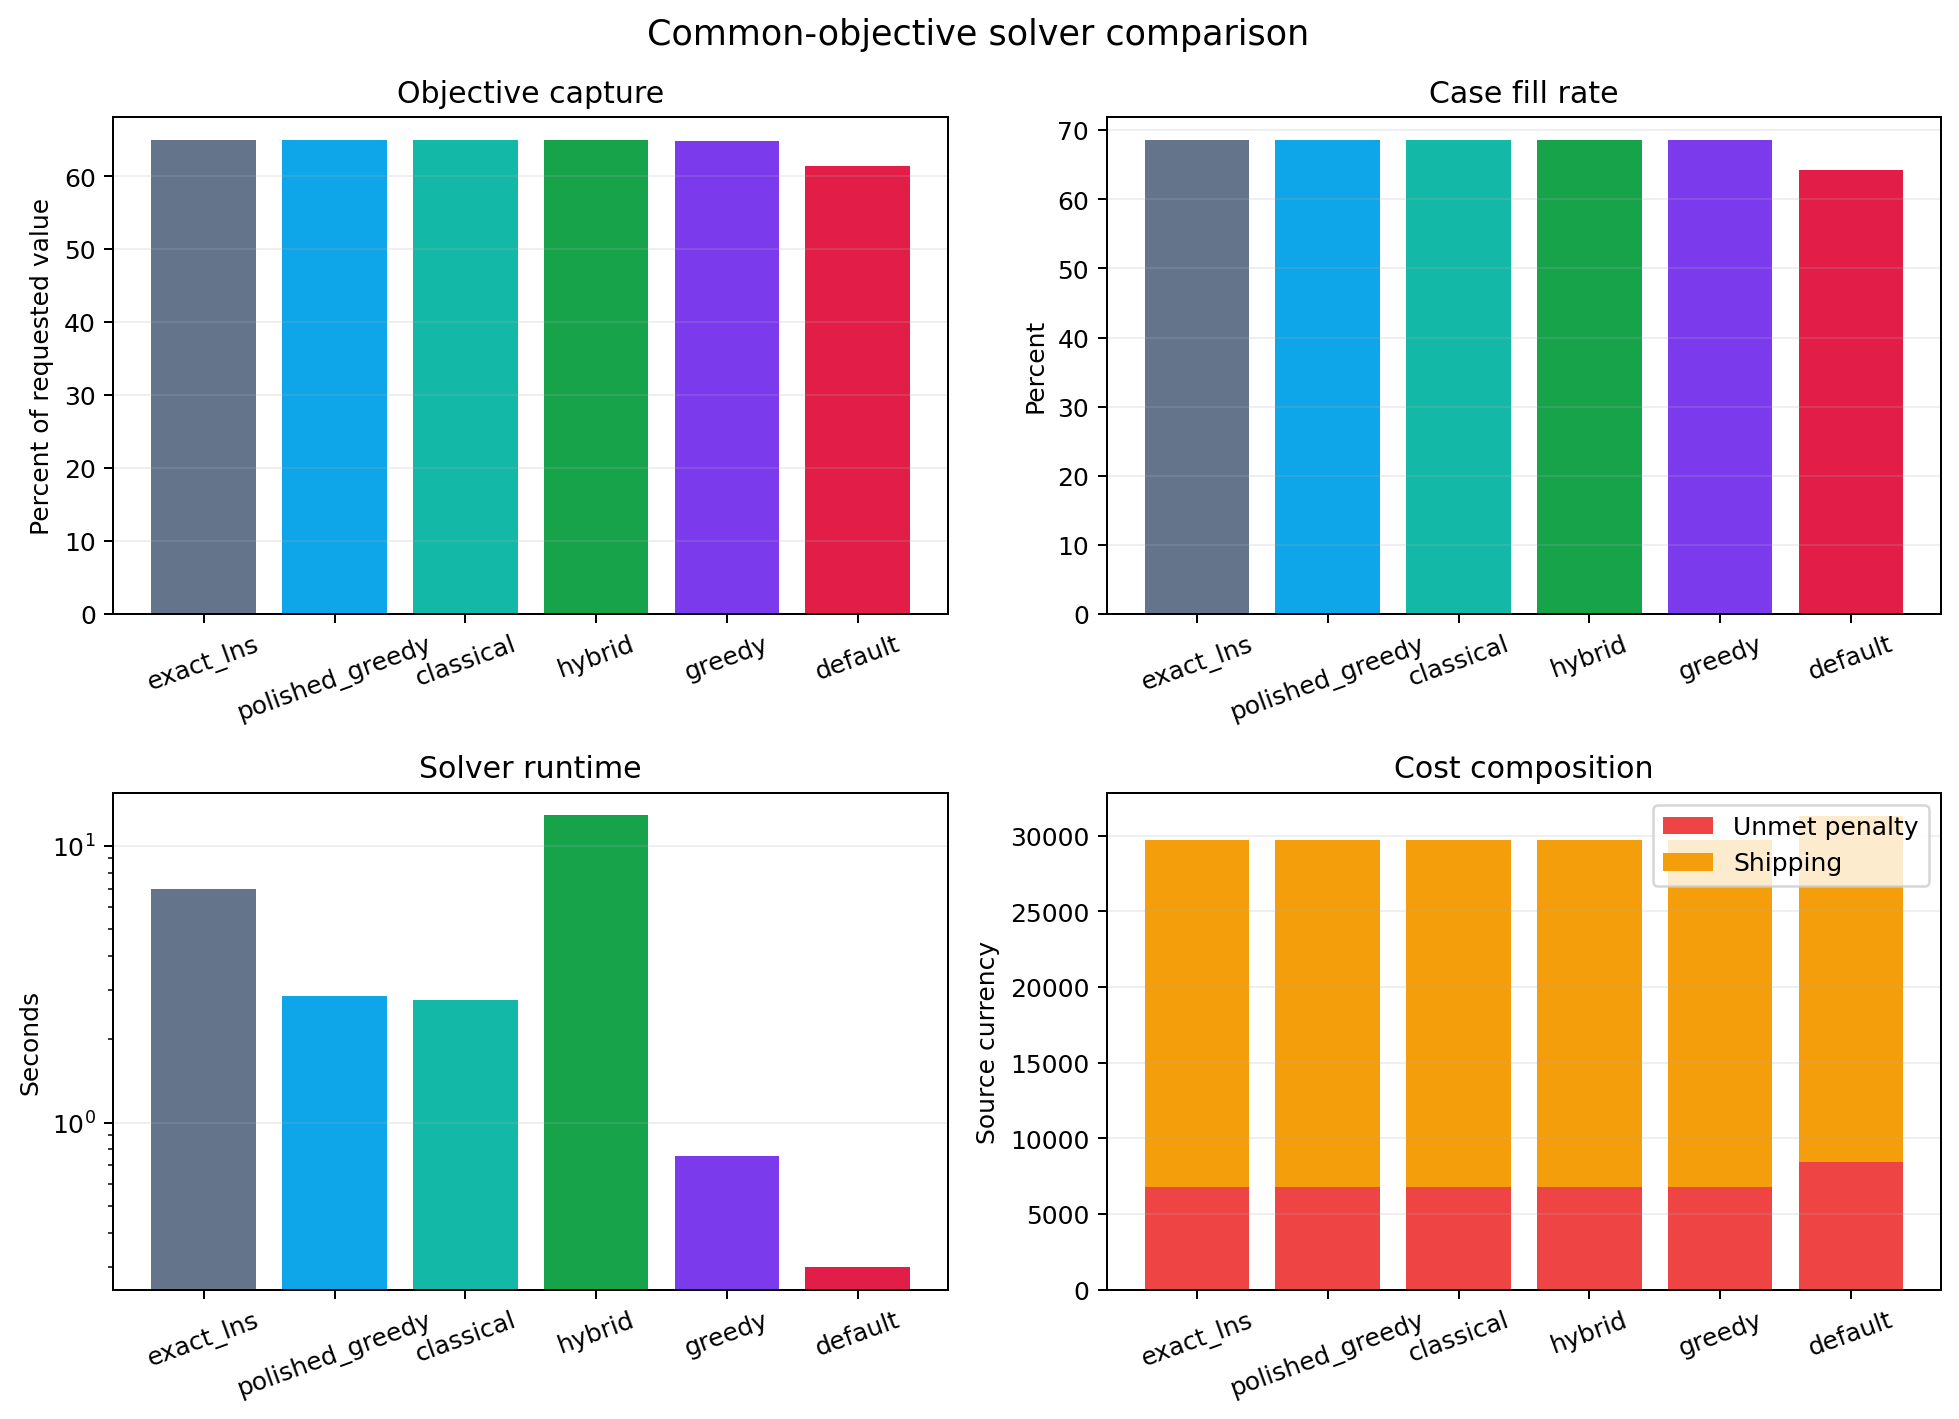

### Solver Frontier

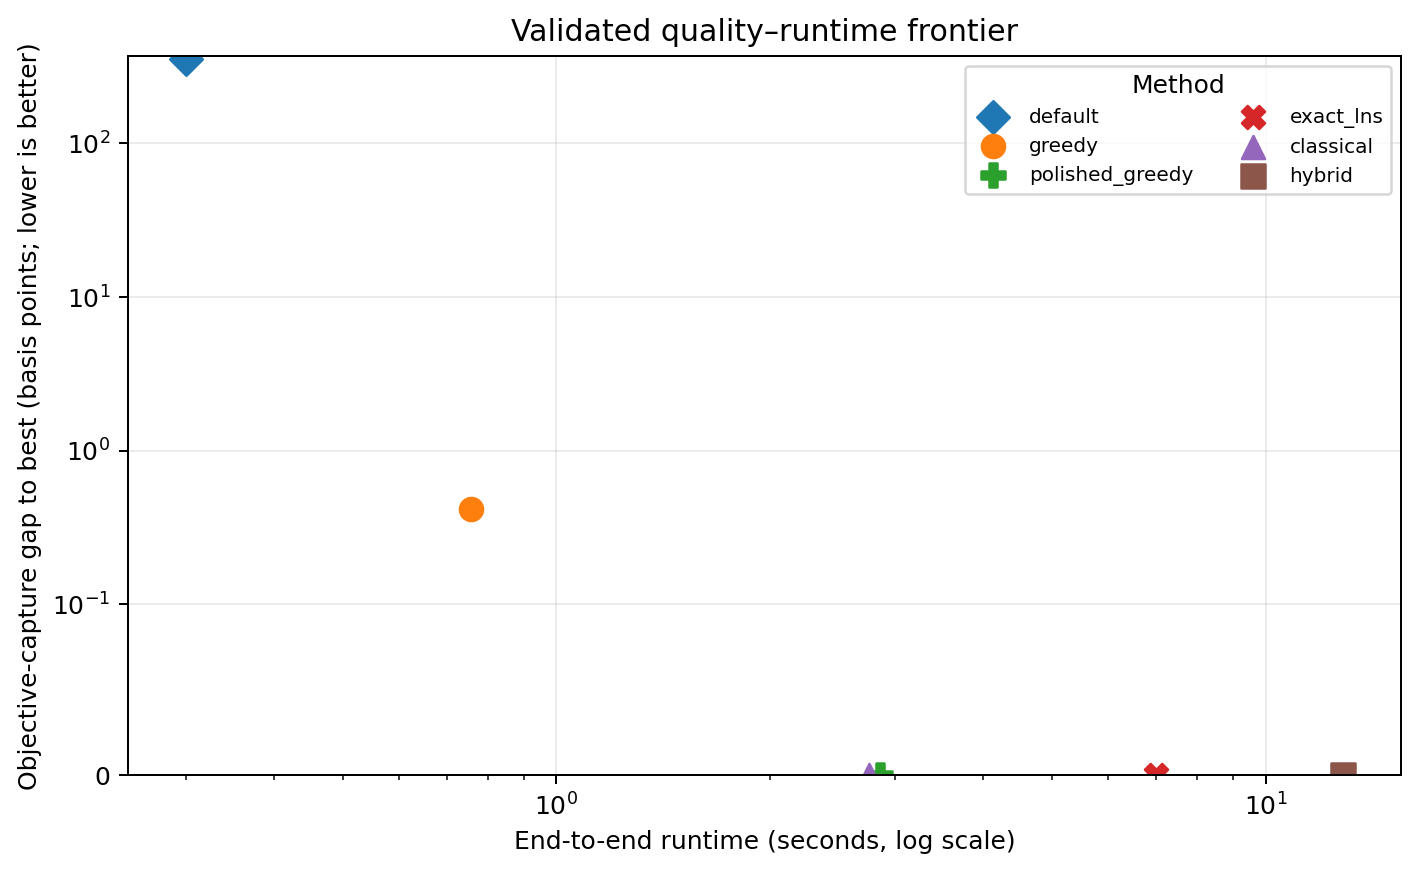

### Size Scaling

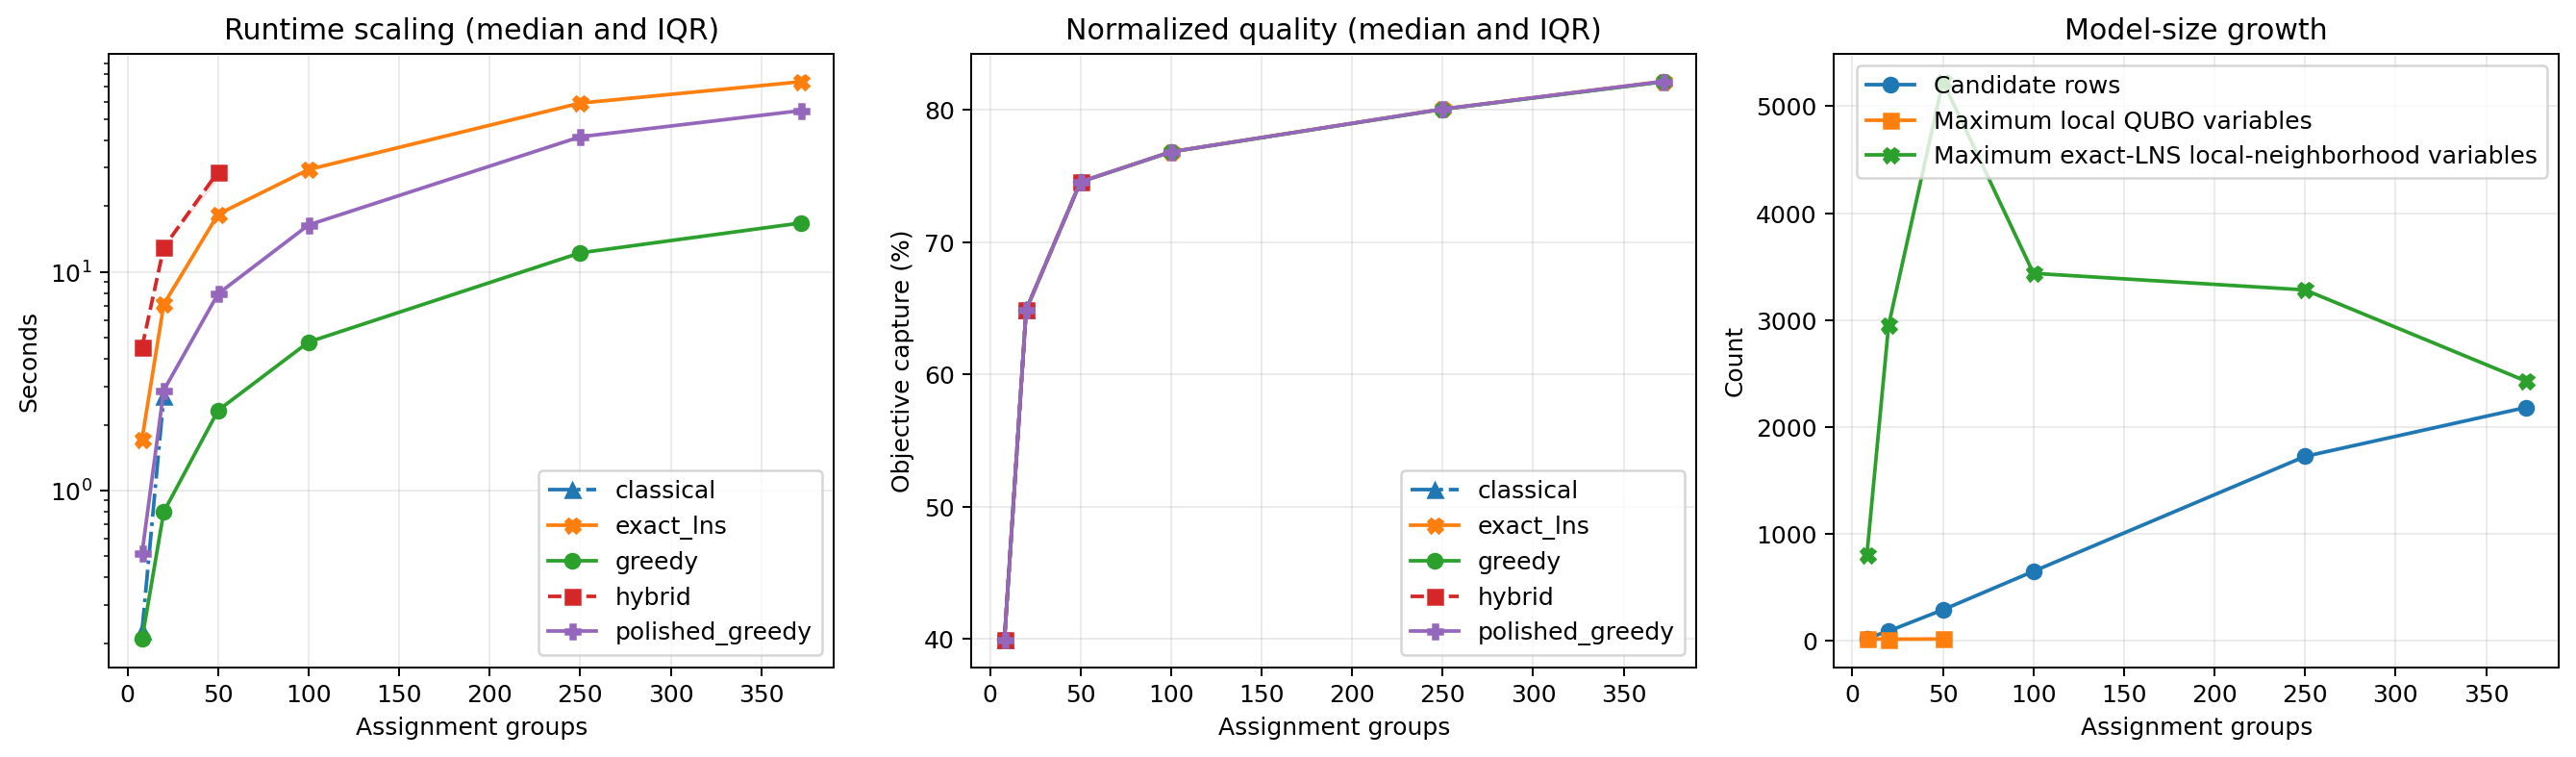

### Synthetic Scaling

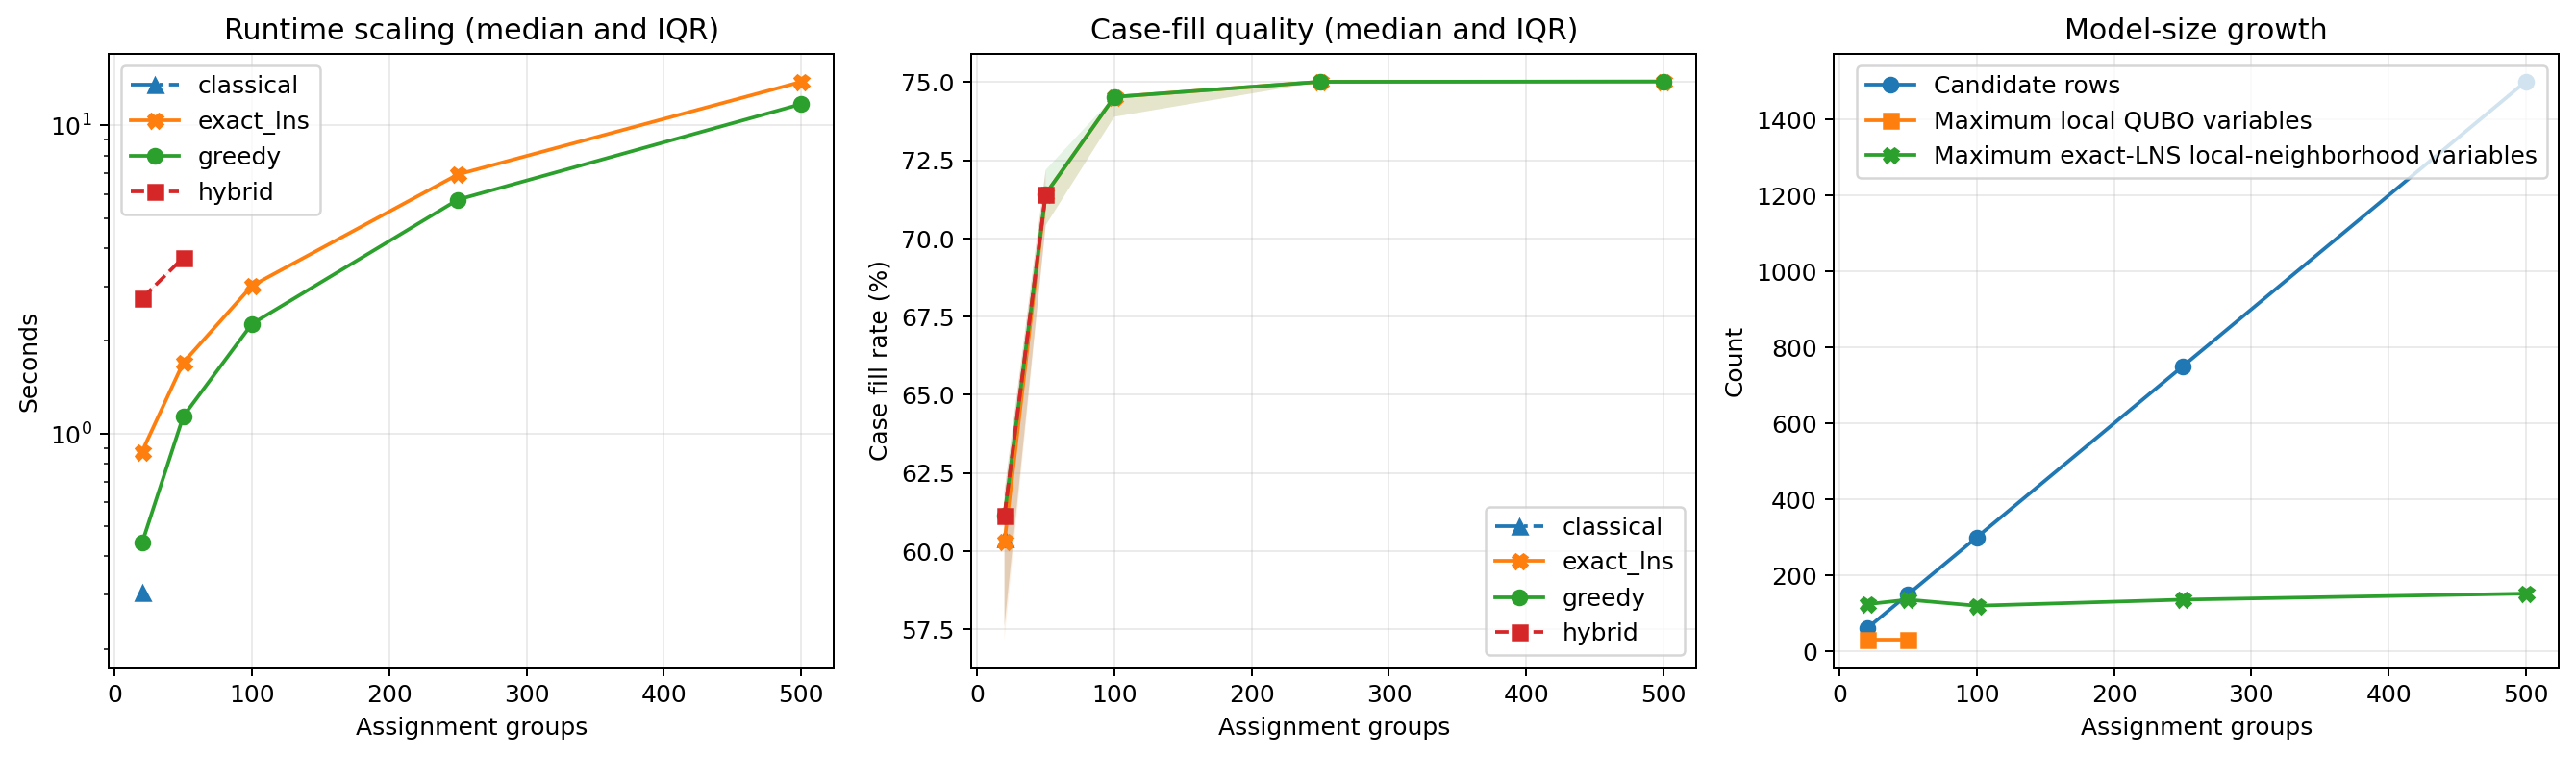

### Candidate Dc Scope Sensitivity

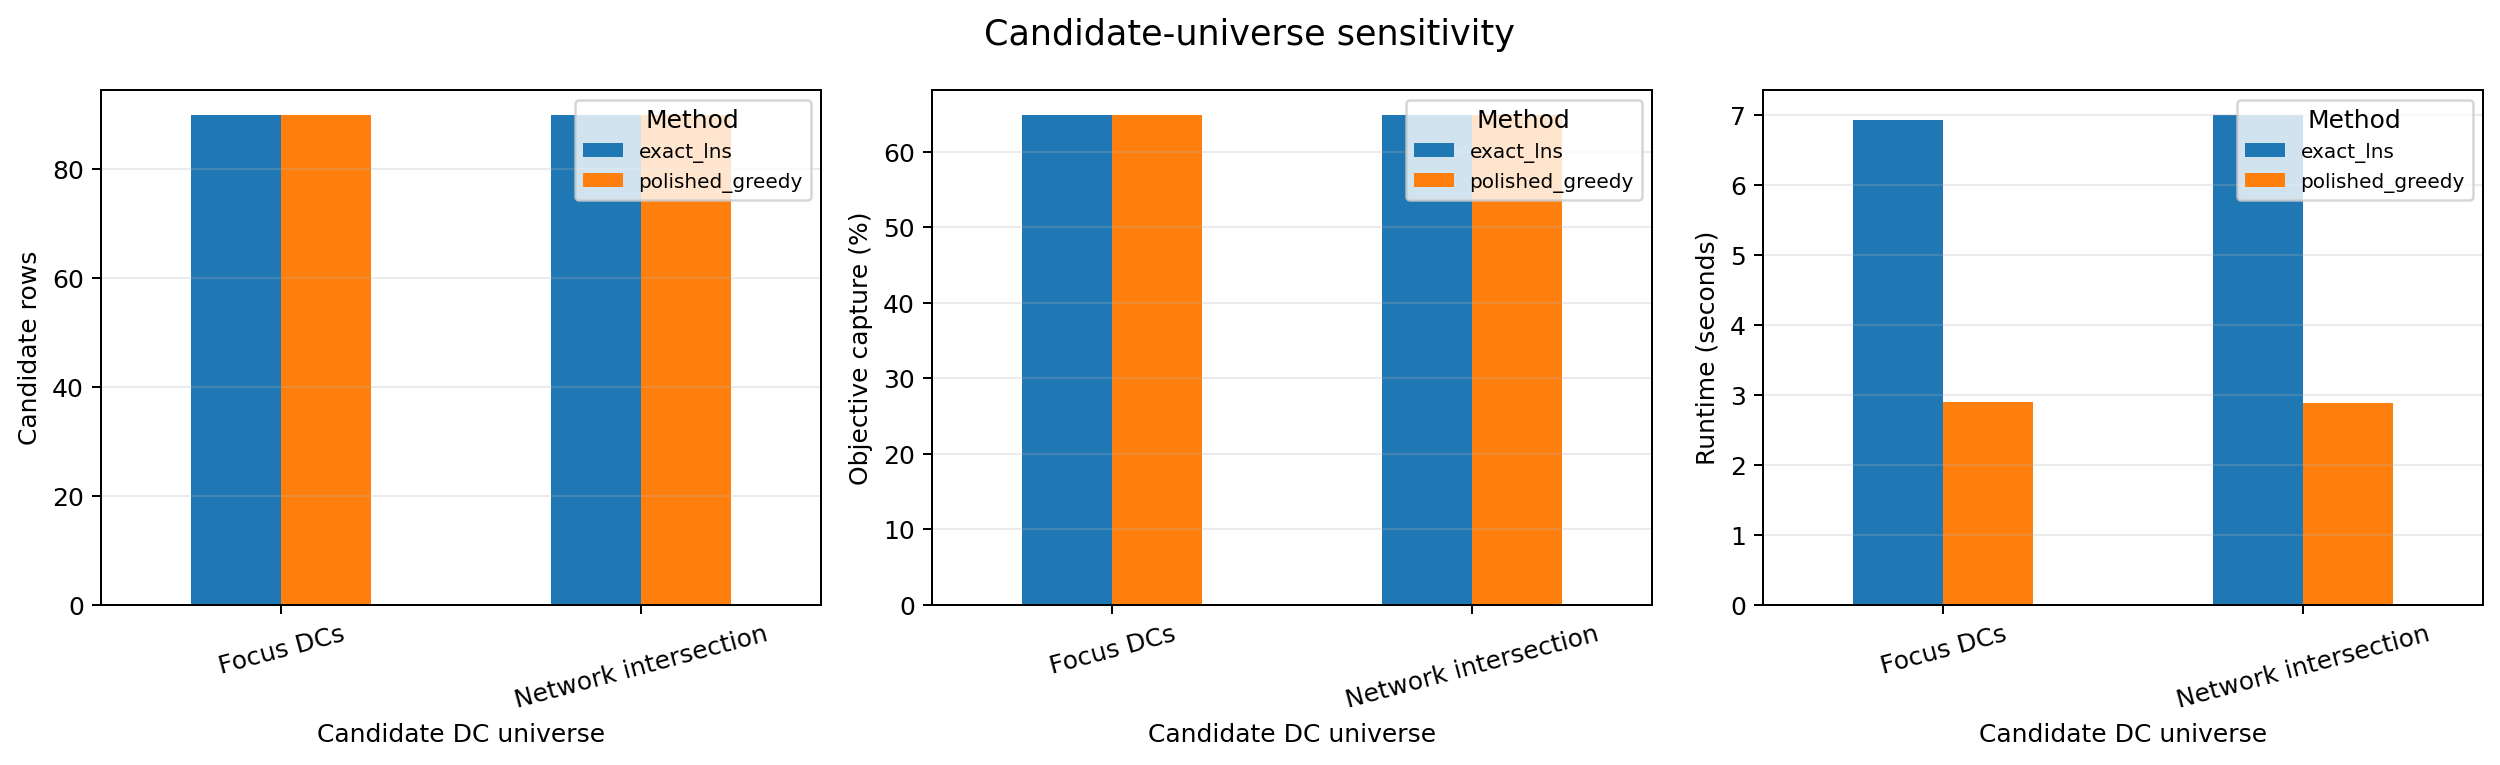

### Business Penalty Sensitivity

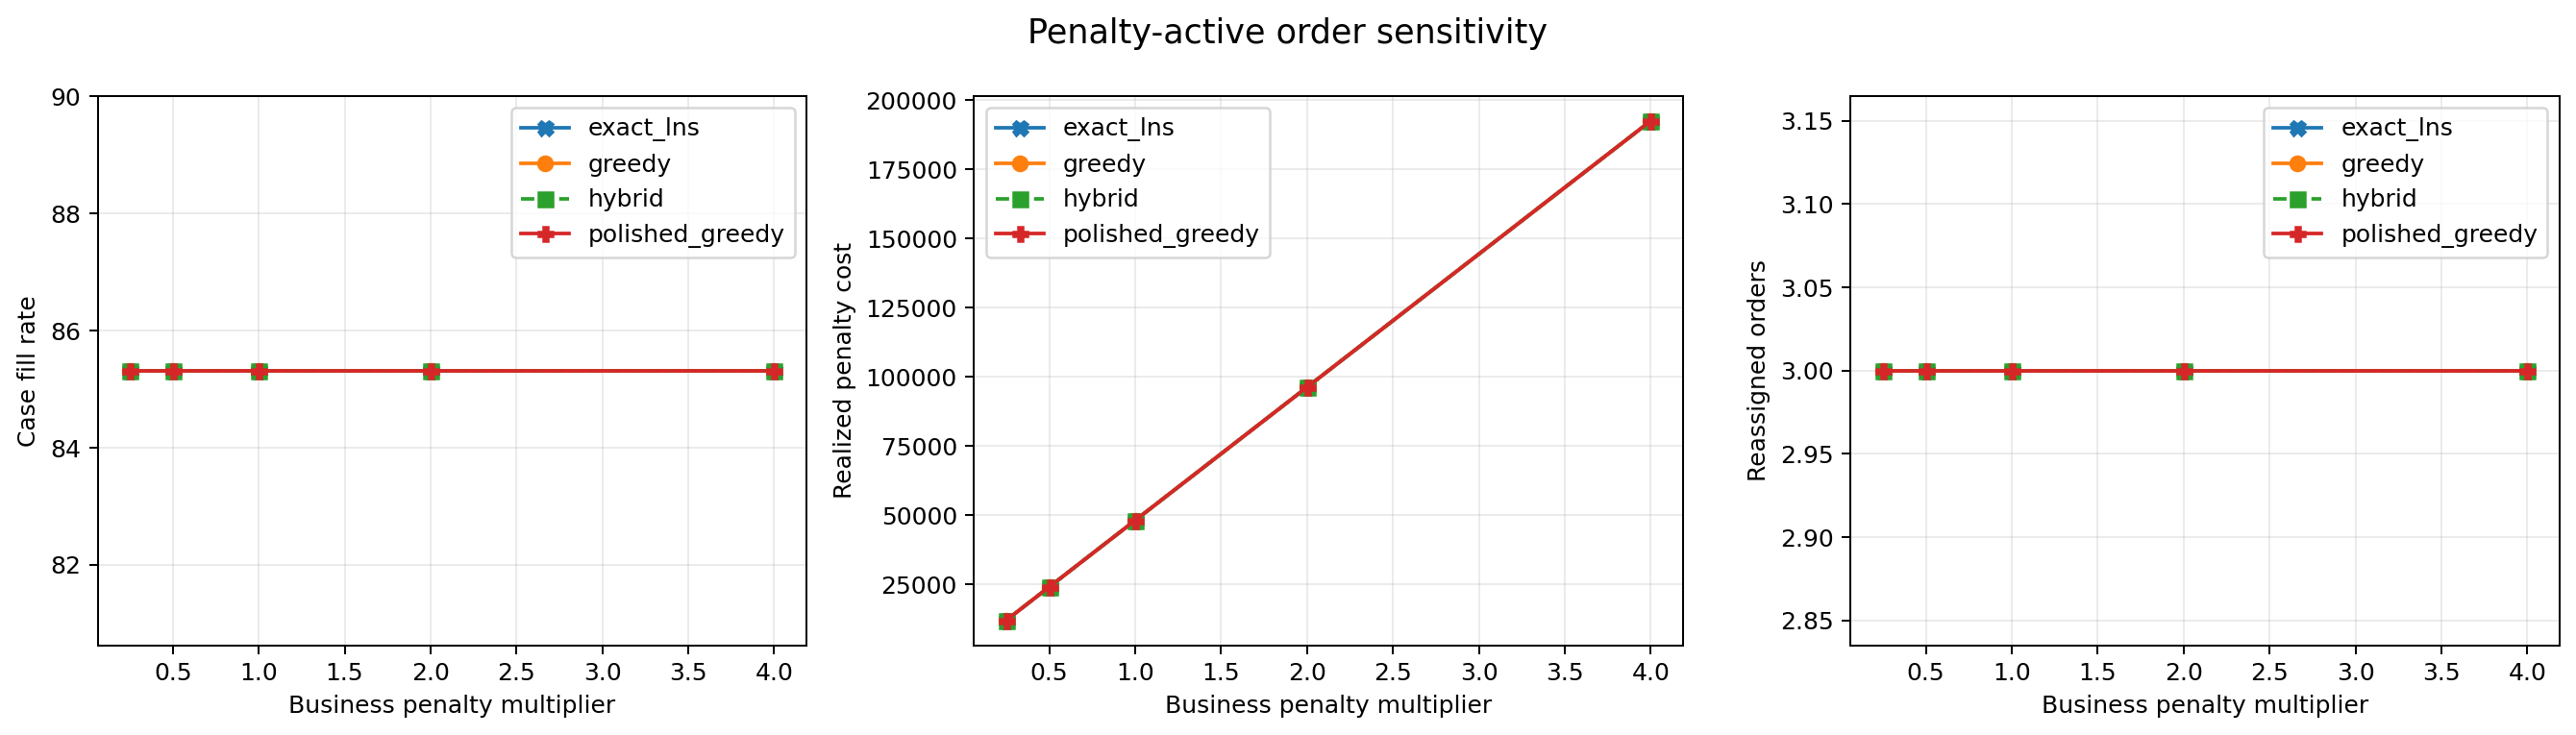

### Candidate Count Sensitivity

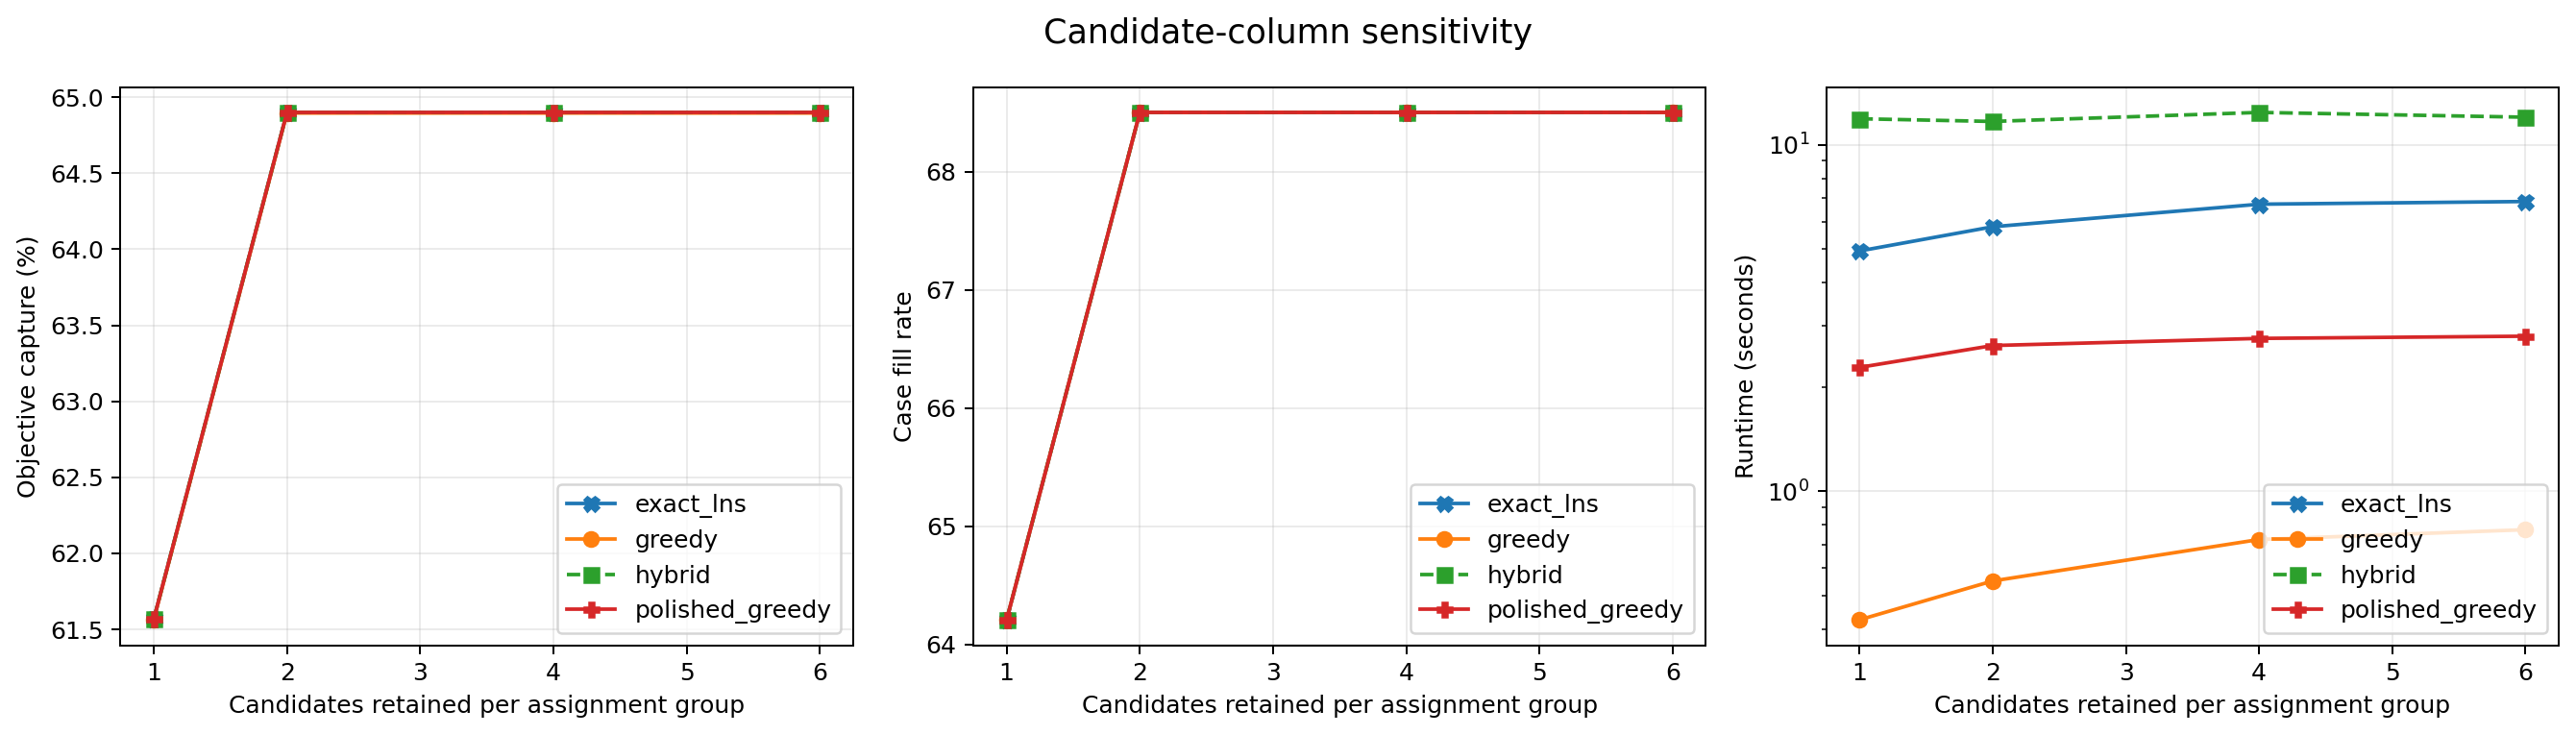

### Inventory Shock

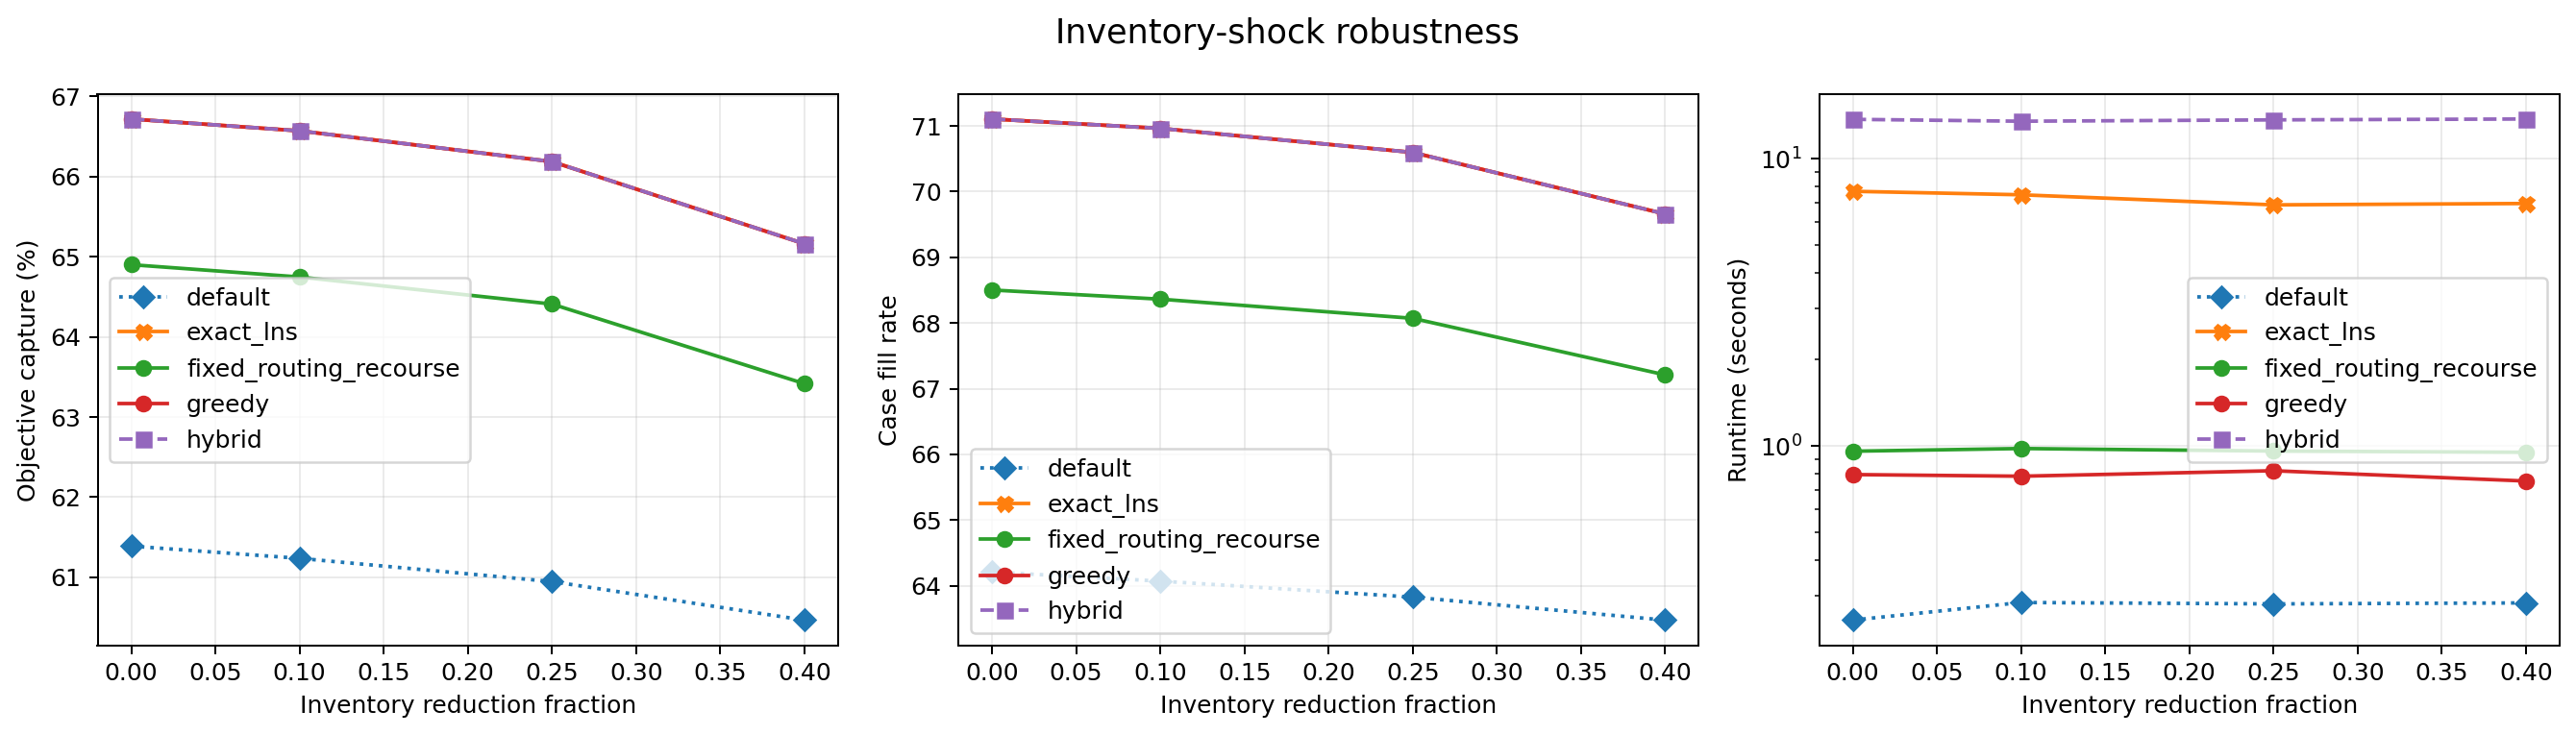

### Qubo Coefficient Noise

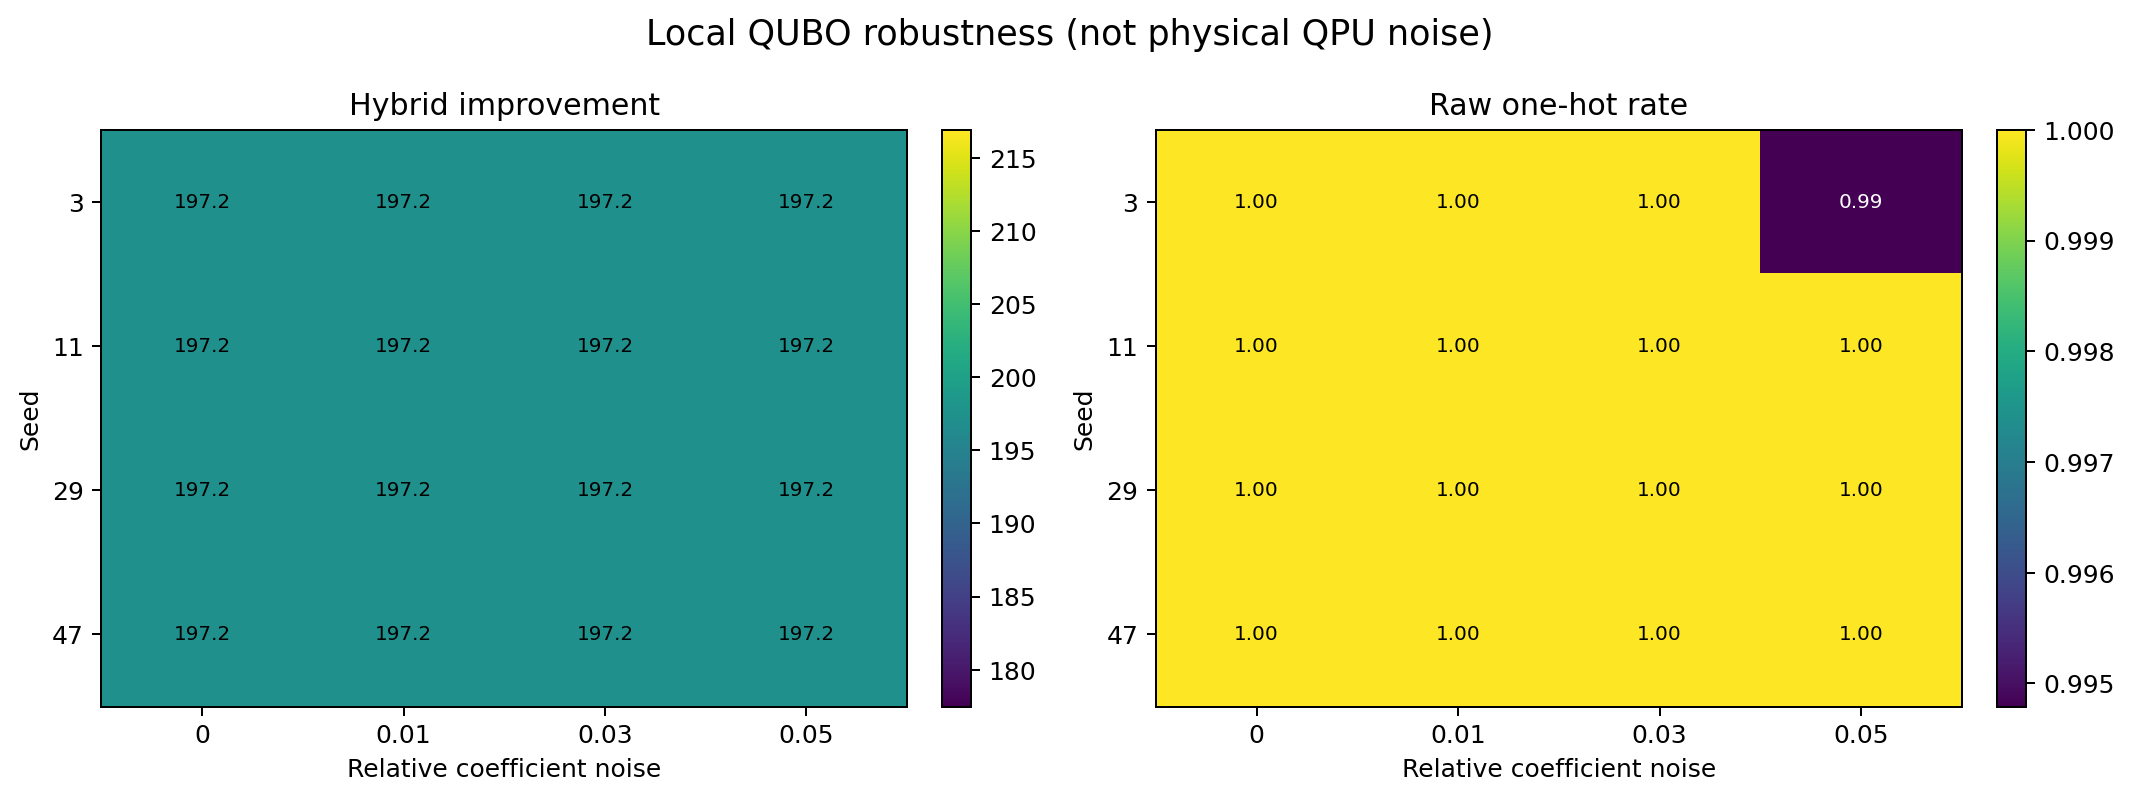

### Qaoa Readout Noise

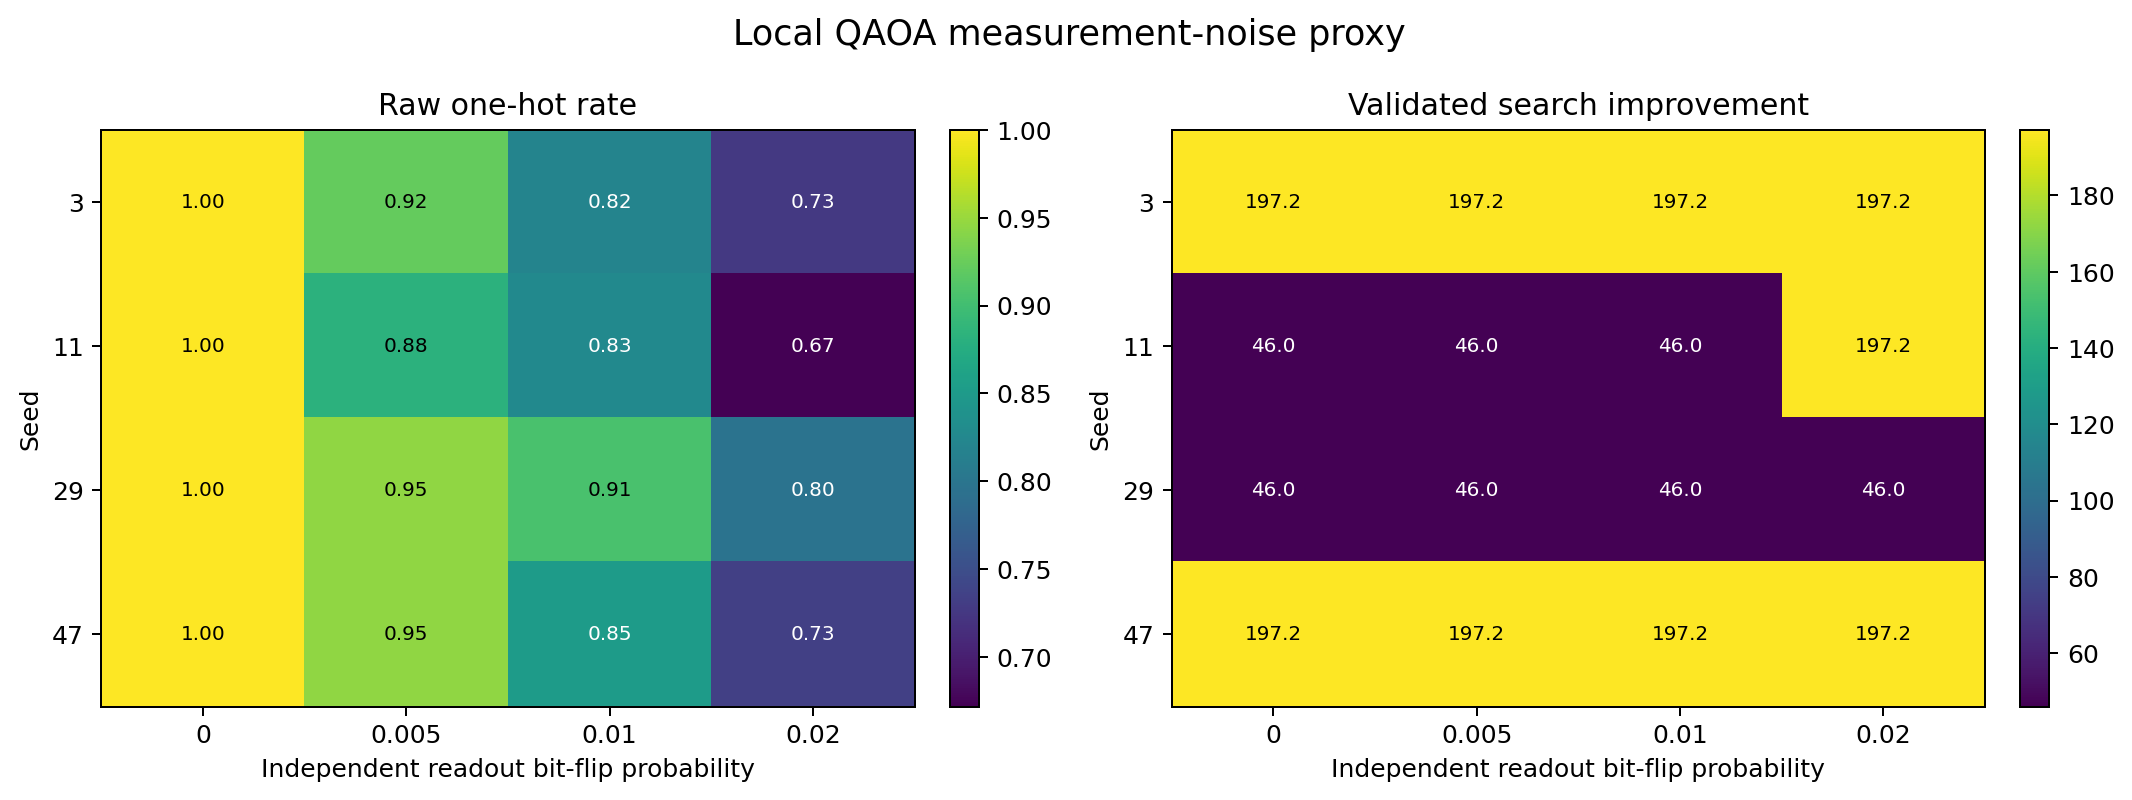

### Qubo Penalty Sensitivity

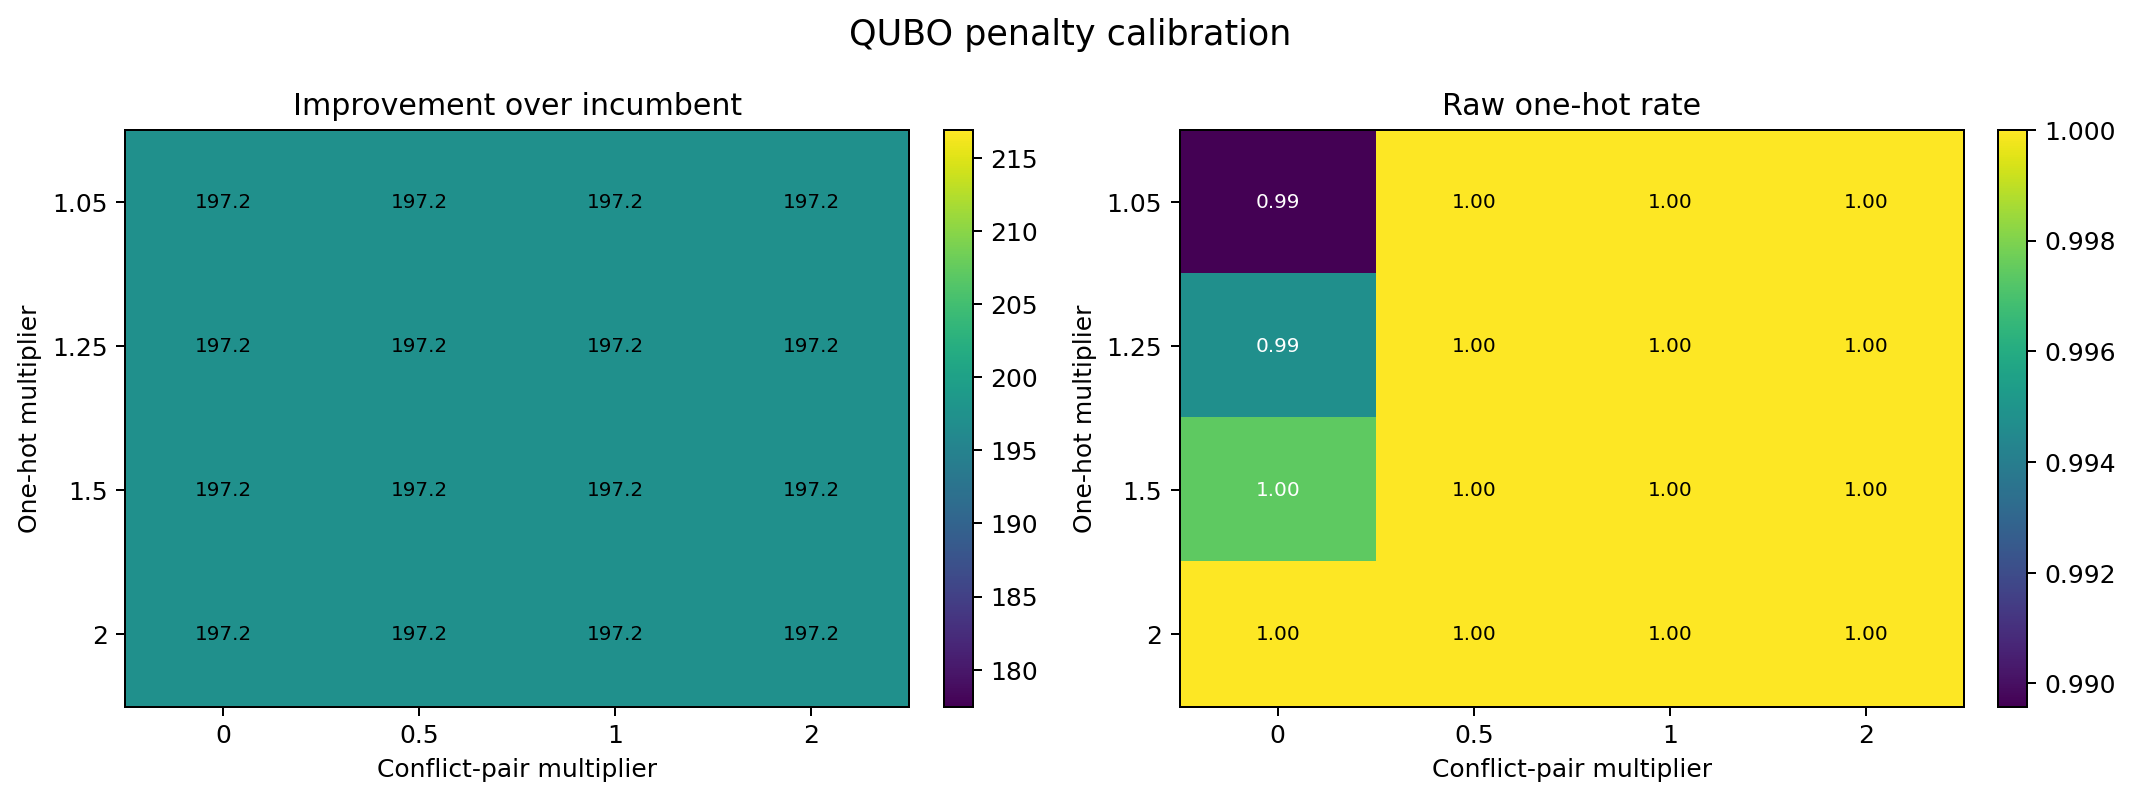

### Ablations

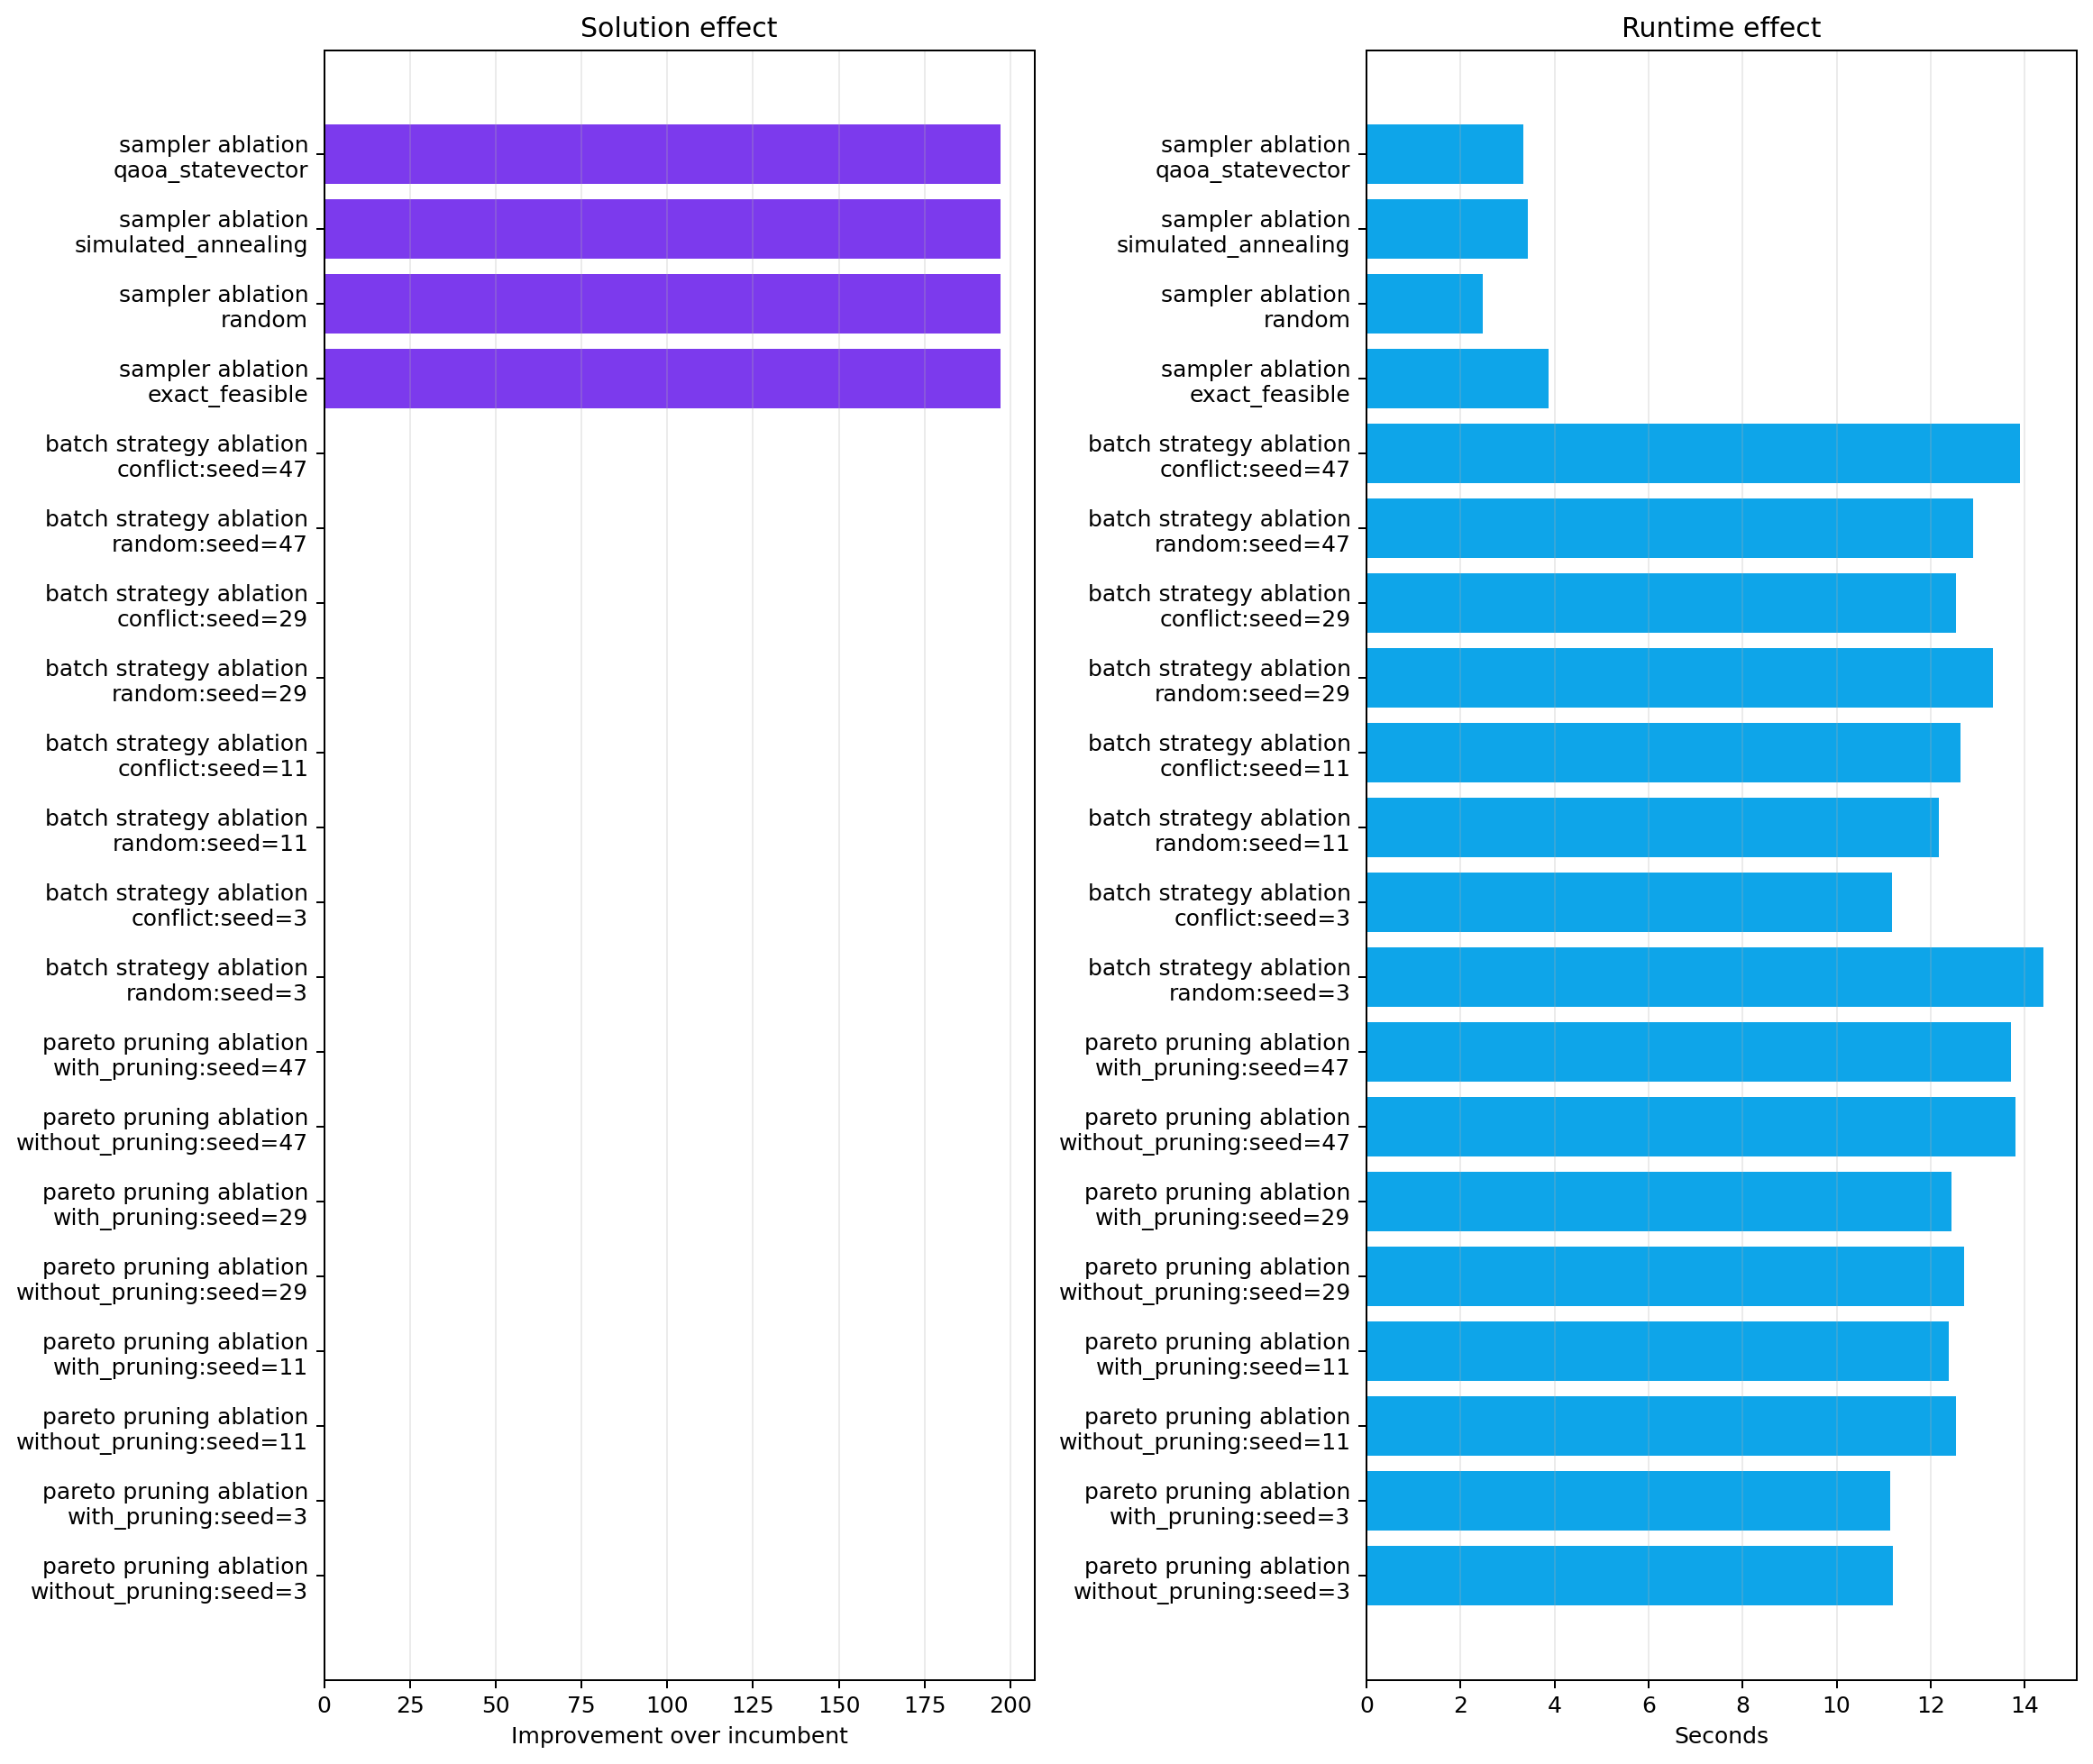

### Hybrid Timing

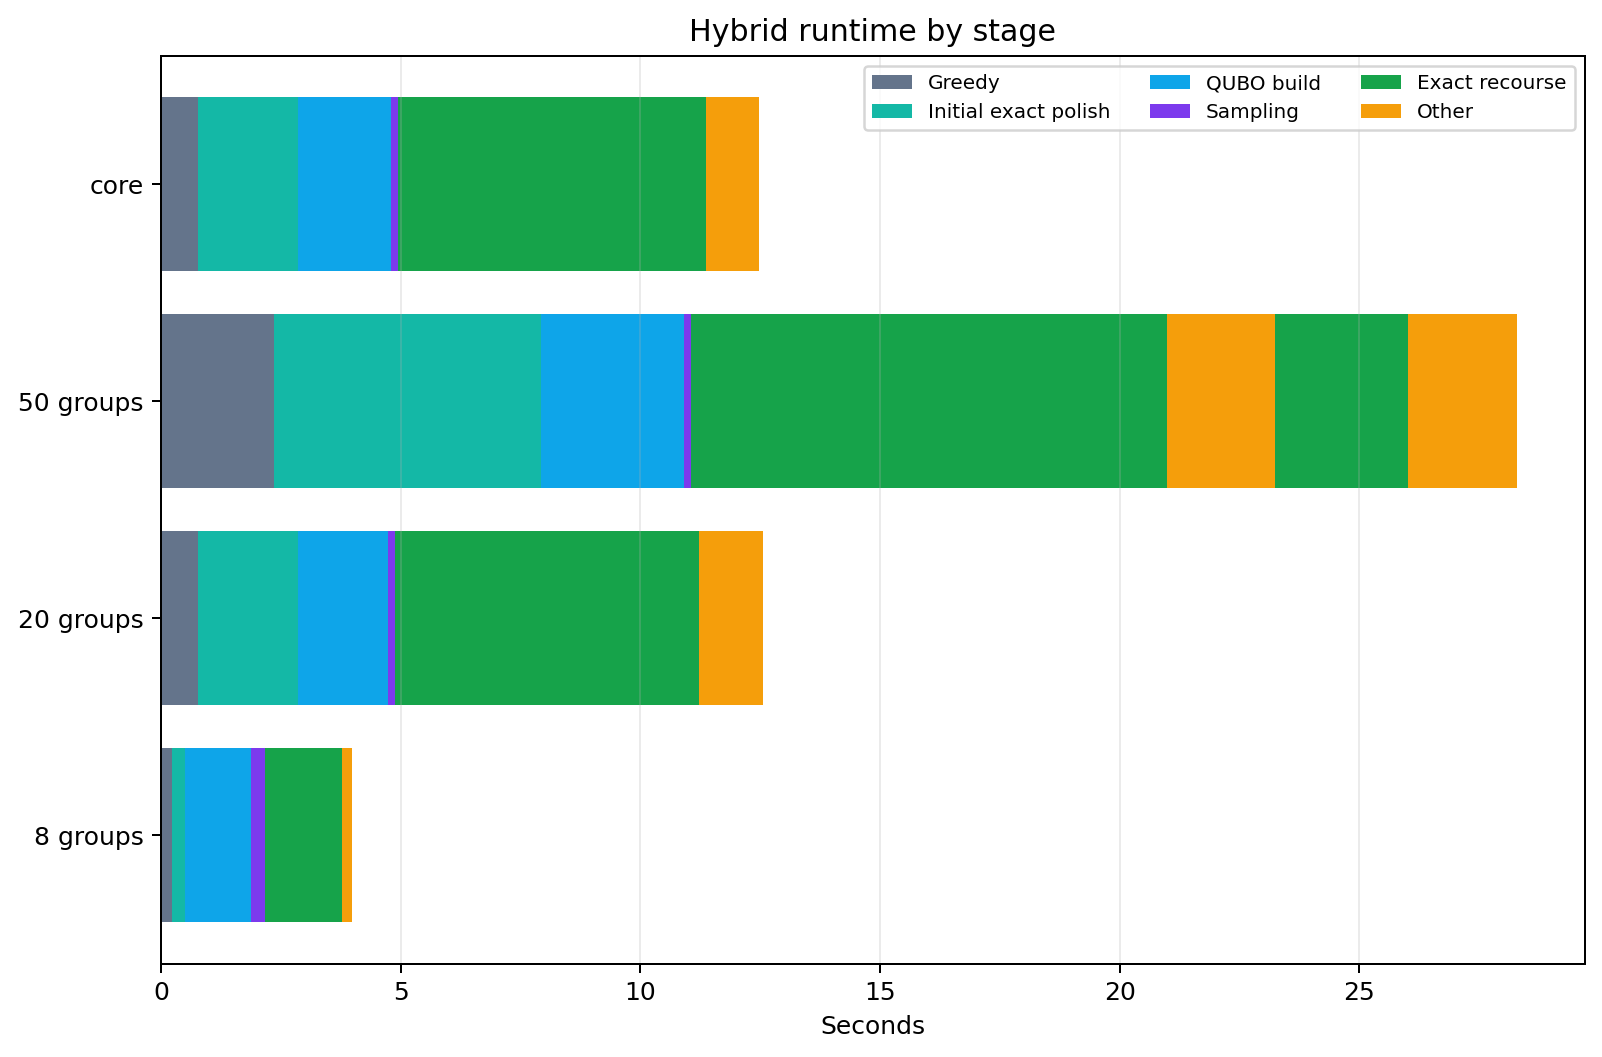

### Synthetic Coordination Control

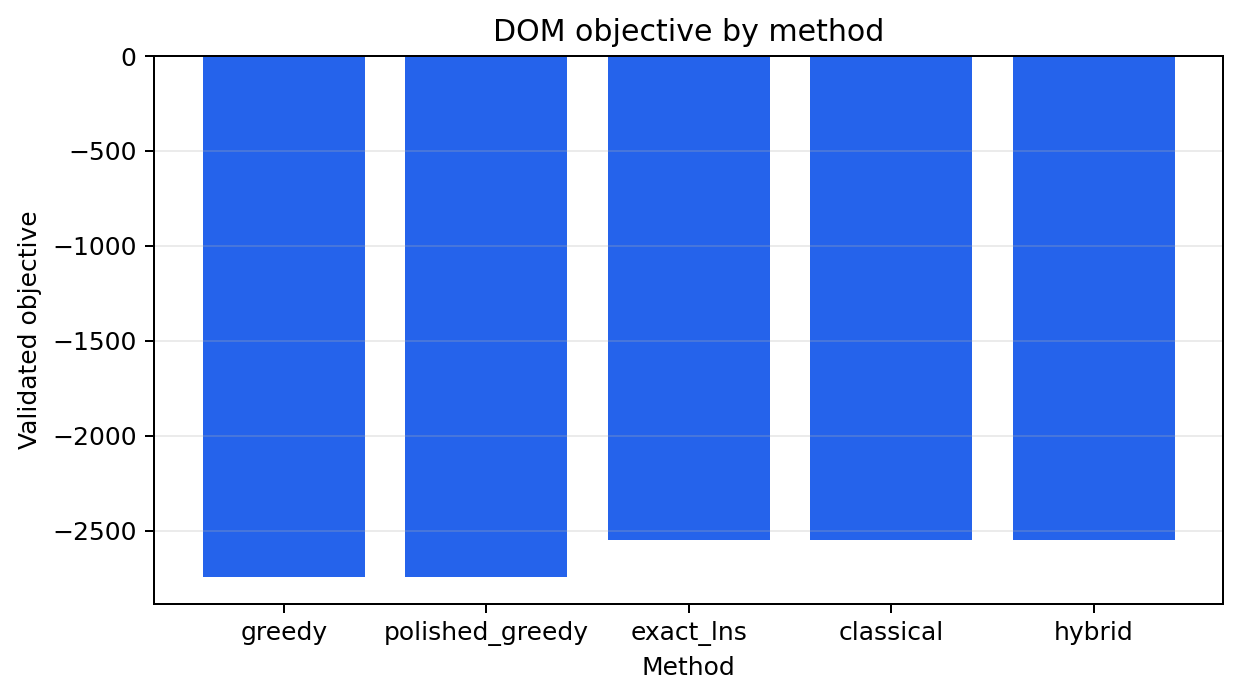

saved 14 figures in results/challenge-study/notebook/full/figures


In [20]:
prepared_frames = [
    frame.dropna(axis=1, how="all")
    for frame in experiment_frames.values()
]
if prepared_frames:
    results = pd.concat(prepared_frames, ignore_index=True, sort=False)
    aggregate_identity = checkpoint_identity(
        problem_unpruned,
        profile=PROFILE,
        experiment="aggregate_results",
        configuration=PROFILE_CONFIGURATION,
    )
    aggregate_path = write_experiment_results(
        results, OUTPUT_DIR / "aggregate_results.csv"
    )
    write_checkpoint(results, aggregate_path, aggregate_identity)
    figure_paths = plot_challenge_results(results, FIGURE_DIR)
    print(
        f"wrote {len(results)} aggregate rows to "
        f"{aggregate_path.relative_to(PROJECT_ROOT)}"
    )
    for name, path in figure_paths.items():
        display(Markdown(f"### {name.replace('_', ' ').title()}"))
        display(Image(filename=str(path)))
    print(
        f"saved {len(figure_paths)} figures in "
        f"{FIGURE_DIR.relative_to(PROJECT_ROOT)}"
    )
else:
    print("No experiment families were enabled; no aggregate was written.")


## 19. Optional GPU crossover benchmark

**Purpose.** Measure synthetic batched QUBO energy scoring on CPU and, when available,
GPU; enable it with `ENABLE_GPU_BENCHMARK = True` in the global cell.

**Why it matters.** Current local QUBOs are small and exact recourse is CPU-based, so
GPU launch/transfer overhead may dominate. This locates a scoring crossover without
claiming end-to-end solver acceleration.


python                                                       3.10.20
logical_cpu_count                                                 32
cupy_available                                                  True
cuda_device_count                                                  1
cuda_device_name                          NVIDIA GeForce RTX 3090 Ti
cuda_memory_gib                                            23.546143
cuopt_available                                                False
qiskit_available                                                True
qiskit_ibm_runtime_available                                    True
ibm_credentials_environment_configured                         False
ibm_saved_account_count                                            1
ibm_saved_account_available                                     True
Name: hardware capability, dtype: object

,backend,variables,samples,compute_seconds,transfer_seconds,samples_per_second,end_to_end_seconds,end_to_end_samples_per_second
0,numpy_cpu,16,256,0.000066,0.000000,3.906958e+06,0.000066,3.906958e+06
1,cupy_gpu,16,256,0.000193,0.109022,1.323514e+06,0.109216,2.343986e+03
2,numpy_cpu,16,4096,0.000327,0.000000,1.252491e+07,0.000327,1.252491e+07
3,cupy_gpu,16,4096,0.000193,0.000171,2.123757e+07,0.000364,1.126480e+07
4,numpy_cpu,40,256,0.000086,0.000000,2.976802e+06,0.000086,2.976802e+06
5,cupy_gpu,40,256,0.000197,0.000082,1.297769e+06,0.000279,9.176300e+05
6,numpy_cpu,40,4096,0.001342,0.000000,3.052969e+06,0.001342,3.052969e+06
7,cupy_gpu,40,4096,0.000243,0.001593,1.684482e+07,0.001836,2.230609e+06
8,numpy_cpu,96,256,0.000185,0.000000,1.387403e+06,0.000185,1.387403e+06
9,cupy_gpu,96,256,0.000245,0.000102,1.046245e+06,0.000347,7.376342e+05


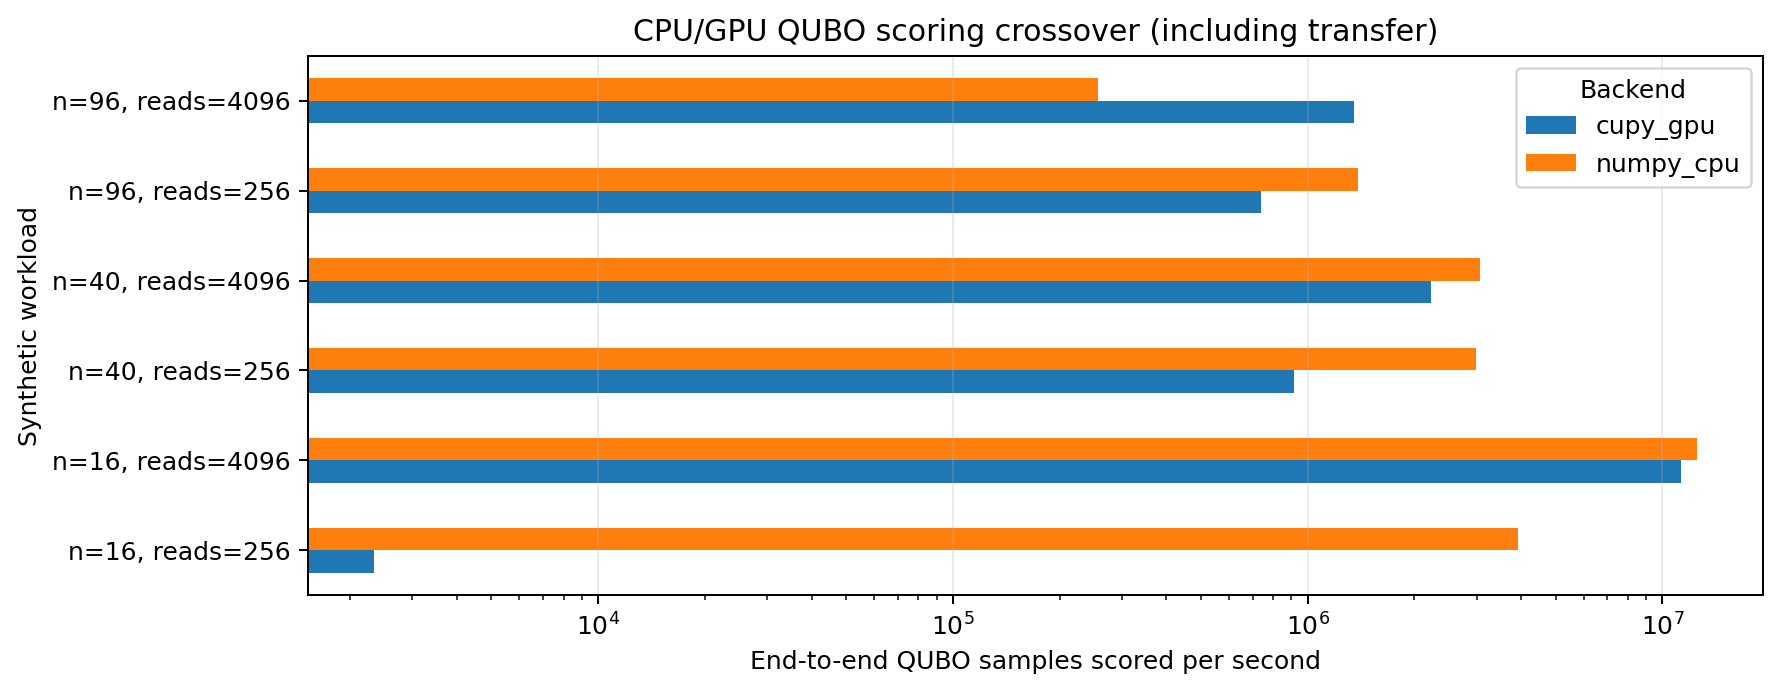

In [21]:
capabilities = hardware_capabilities()
display(pd.Series(capabilities, name="hardware capability"))
if ENABLE_GPU_BENCHMARK:
    hardware_results = benchmark_qubo_batch_scoring(include_gpu=True)
    hardware_path = OUTPUT_DIR / "hardware_qubo_scoring.csv"
    hardware_results.to_csv(hardware_path, index=False)
    hardware_figure = plot_hardware_benchmark(
        hardware_results,
        FIGURE_DIR / "hardware_qubo_scoring.png",
    )
    display(hardware_results)
    display(Image(filename=str(hardware_figure)))
else:
    print("GPU benchmark skipped by the global switch.")


## 20. IBM backend discovery and hardware stress test

**Purpose.** Compare exact, local simulator, and IBM Dicke/XY-QAOA on the same
independently generated coupled control. The full matrix is two depths by three
mitigation strategies: `quick` submits six QPU jobs; `presentation` repeats them three
times for eighteen. Enable it at the top with `ENABLE_IBM_HARDWARE = True`.

**Why it matters.** It separates raw feasible-QUBO hit quality from exact recourse and
final validated gain, while recording compilation, queue, execution, quantum-use, and
decode timings. No Nestlé values or identifiers are sent. This is hardware-quality
evidence—not a quantum-advantage claim—and requires an already configured IBM account.


,backend,num_qubits,pending_jobs,operational,status_message,selected_least_busy,selected_for_study
0,ibm_marrakesh,156,0,True,active,True,True
1,ibm_kingston,156,1,True,active,False,False
2,ibm_fez,156,2,True,active,False,False


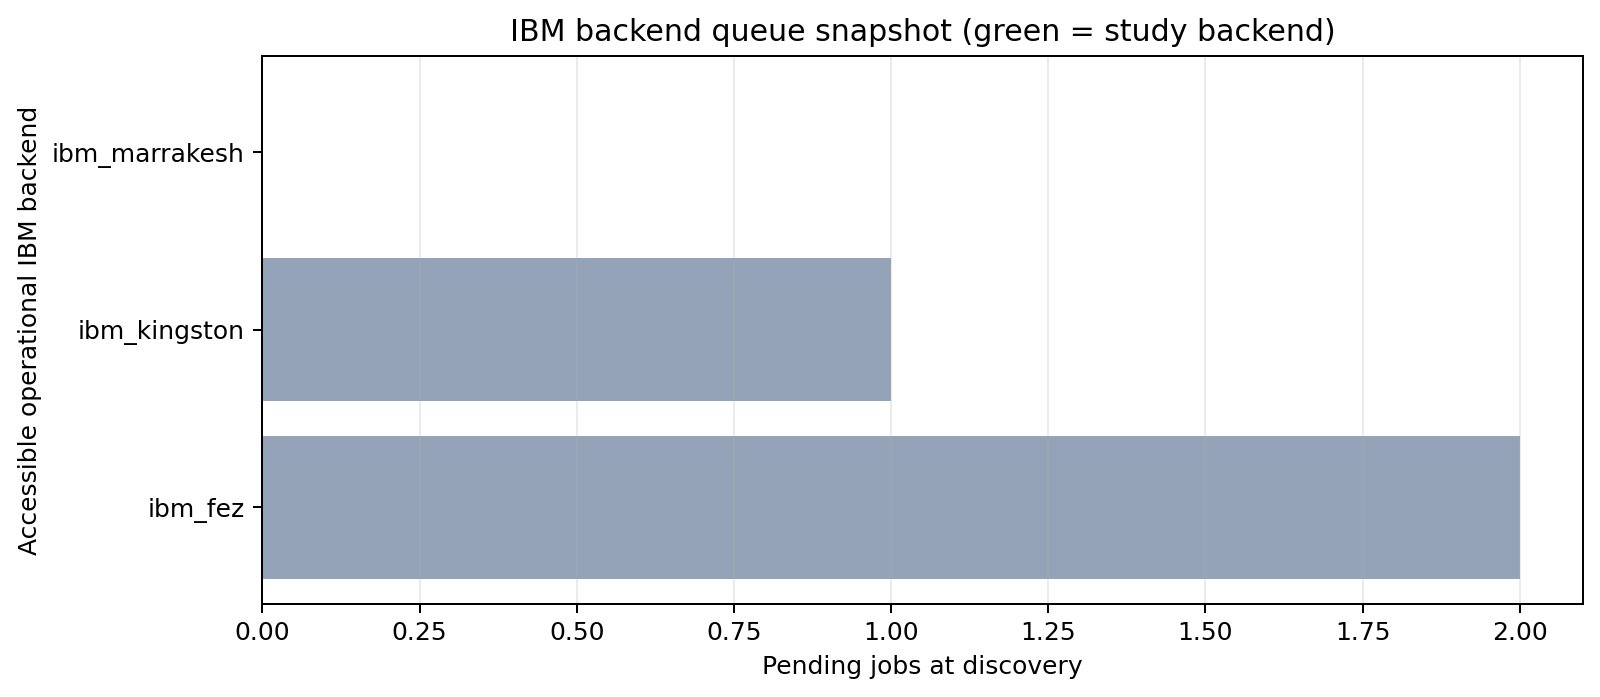

no reusable IBM checkpoint (checkpoint CSV or manifest is missing)


,level,hardware_backend,hardware_mitigation_strategy,qaoa_layers,feasible,search_improvement,raw_one_hot_rate,hardware_qubo_optimal_hit_rate,hardware_transpiled_depth,hardware_two_qubit_gates,hardware_queue_seconds,hardware_execution_seconds,hardware_quantum_seconds,hardware_returned_samples,hardware_feasible_shots,runtime_seconds
0,greedy_reference,None,None,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.097987
1,exact_reference,None,None,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.035652
2,local_qaoa:p=1:angle_seed=3,None,None,1.0,True,197.2,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.507390
3,local_qaoa:p=2:angle_seed=3,None,None,2.0,True,197.2,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.276595
4,local_qaoa:p=1:angle_seed=11,None,None,1.0,True,197.2,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.624109
5,local_qaoa:p=2:angle_seed=11,None,None,2.0,True,197.2,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.590159
6,local_qaoa:p=1:angle_seed=29,None,None,1.0,True,197.2,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.429768
7,local_qaoa:p=2:angle_seed=29,None,None,2.0,True,197.2,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.650366
8,ibm:p=1:baseline:hardware_rep=1,ibm_marrakesh,baseline,1.0,True,197.2,0.546875,0.001953,138.0,122.0,1.873103,3.766209,NaN,512.0,280.0,83.258304
9,ibm:p=1:dynamical_decoupling:hardware_rep=1,ibm_marrakesh,dynamical_decoupling,1.0,True,197.2,0.468750,0.001953,138.0,122.0,1.456260,4.064925,NaN,512.0,240.0,86.658616


,rank,selected_best_observed,qaoa_layers,hardware_mitigation_strategy,attempted_runs,hardware_qubo_optimal_hit_rate,raw_one_hot_rate,search_improvement,hardware_two_qubit_gates,hardware_quantum_seconds,...,runtime_seconds,successful_runs,hardware_qubo_optimal_hit_rate_q25,hardware_qubo_optimal_hit_rate_q75,raw_one_hot_rate_q25,raw_one_hot_rate_q75,runtime_seconds_q25,runtime_seconds_q75,success_rate,variant
0,1,True,1.0,dd_measure_twirling,3,0.003906,0.531250,197.2,122.0,2.764122,...,84.562498,3,0.003906,0.005859,0.500977,0.550781,84.484884,91.274367,1.0,p=1 | dd_measure_twirling
1,2,False,1.0,baseline,3,0.001953,0.589844,197.2,122.0,1.800695,...,83.258304,3,0.000977,0.001953,0.568359,0.592773,83.215713,86.066141,1.0,p=1 | baseline
2,3,False,1.0,dynamical_decoupling,3,0.001953,0.507812,197.2,122.0,1.800695,...,86.965715,3,0.000977,0.003906,0.488281,0.512695,86.812166,90.130237,1.0,p=1 | dynamical_decoupling
3,4,False,2.0,baseline,3,0.000000,0.152344,197.2,420.0,1.916080,...,16.830662,3,0.000000,0.000000,0.150391,0.170898,16.205777,16.857692,1.0,p=2 | baseline
4,5,False,2.0,dynamical_decoupling,3,0.000000,0.142578,197.2,420.0,1.916080,...,15.076290,3,0.000000,0.000977,0.137695,0.151367,14.896302,15.166973,1.0,p=2 | dynamical_decoupling
5,6,False,2.0,dd_measure_twirling,3,0.000000,0.121094,197.2,420.0,3.612572,...,15.659673,3,0.000000,0.000977,0.110352,0.126953,15.178121,15.804330,1.0,p=2 | dd_measure_twirling


**Best observed successful IBM strategy:** p=1 | dd_measure_twirling (median exact feasible-QUBO raw hit rate 0.4%).

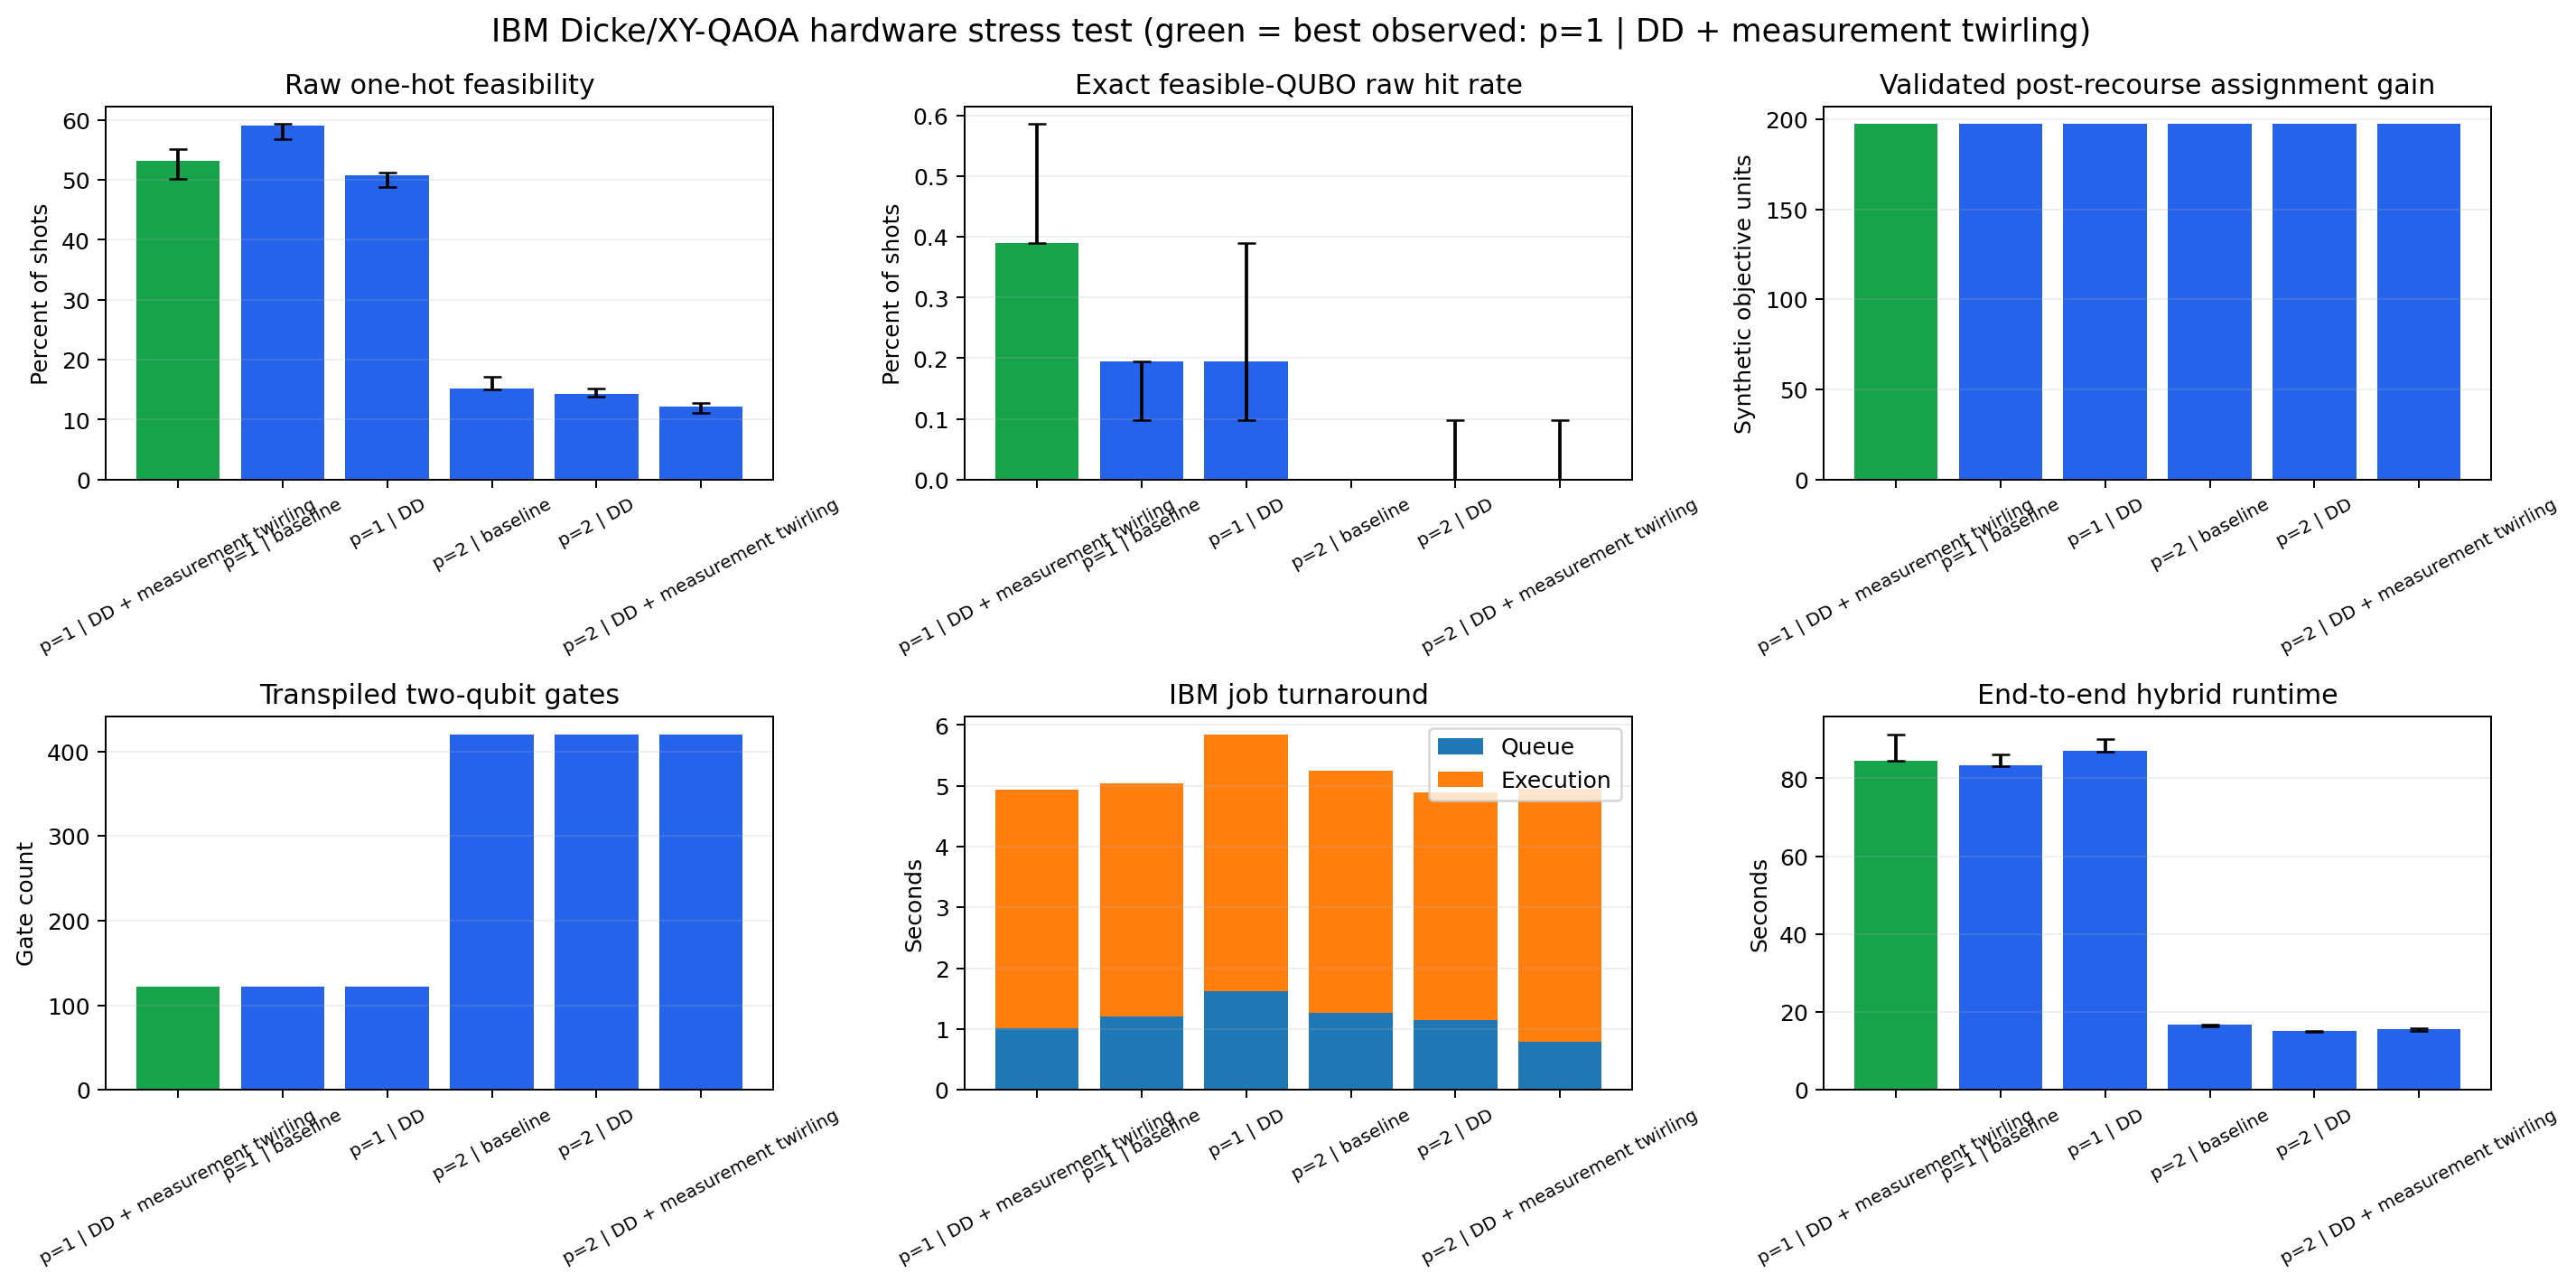

wrote results/challenge-study/notebook/ibm-presentation/tables/ibm_hardware_stress.csv
wrote results/challenge-study/notebook/ibm-presentation/tables/ibm_strategy_ranking.csv


In [22]:
if ENABLE_IBM_HARDWARE:
    logical_qubits = ibm_hardware_study_logical_qubits()
    backend_snapshot = discover_ibm_backends(min_num_qubits=logical_qubits)
    selected_backend = IBM_BACKEND_NAME or str(
        backend_snapshot.loc[
            backend_snapshot["selected_least_busy"], "backend"
        ].iloc[0]
    )
    if selected_backend not in set(backend_snapshot["backend"].astype(str)):
        raise RuntimeError(
            f"Requested backend {selected_backend!r} is not eligible for this circuit"
        )
    backend_snapshot["selected_for_study"] = (
        backend_snapshot["backend"].astype(str).eq(selected_backend)
    )
    ibm_problem = make_ibm_hardware_study_problem()
    qpu_identity = checkpoint_identity(
        ibm_problem,
        profile=f"ibm-{IBM_HARDWARE_PROFILE}",
        experiment="ibm_hardware_stress",
        configuration={
            "backend": selected_backend,
            "shots": IBM_SHOTS,
            "hardware_profile": IBM_HARDWARE_PROFILE,
            "logical_qubits": logical_qubits,
            "matrix": "p=1,2 x baseline,dd,dd+measurement-twirling",
            "data_scope": "independently generated synthetic control",
        },
    )
    IBM_OUTPUT_DIR = checkpoint_run_directory(OUTPUT_ROOT, qpu_identity)
    IBM_TABLE_DIR = IBM_OUTPUT_DIR / "tables"
    IBM_FIGURE_DIR = IBM_OUTPUT_DIR / "figures"
    IBM_TABLE_DIR.mkdir(parents=True, exist_ok=True)
    IBM_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    backend_path = IBM_OUTPUT_DIR / "ibm_backend_snapshot.csv"
    backend_snapshot.to_csv(backend_path, index=False)
    backend_figure = plot_ibm_backend_snapshot(
        backend_snapshot,
        IBM_FIGURE_DIR / "ibm_backend_queue.png",
    )
    display(backend_snapshot)
    display(Image(filename=str(backend_figure)))

    qpu_target = IBM_TABLE_DIR / "ibm_hardware_stress.csv"
    existing_qpu_results = None
    if not FORCE_RERUN:
        try:
            existing_qpu_results = load_checkpoint(qpu_target, qpu_identity)
            print(f"resuming from {len(existing_qpu_results)} verified rows")
        except StaleCheckpointError as error:
            print(f"no reusable IBM checkpoint ({error})")
    qpu_results = run_ibm_hardware_study(
        allow_remote=True,
        backend_name=selected_backend,
        shots=IBM_SHOTS,
        profile=IBM_HARDWARE_PROFILE,
        progress_callback=lambda frame: write_checkpoint(
            frame, qpu_target, qpu_identity
        ),
        existing_results=existing_qpu_results,
    )
    qpu_path, _ = write_checkpoint(qpu_results, qpu_target, qpu_identity)
    strategy_ranking = rank_ibm_hardware_strategies(qpu_results)
    ranking_path = write_experiment_results(
        strategy_ranking,
        IBM_TABLE_DIR / "ibm_strategy_ranking.csv",
    )
    show_result(
        qpu_results,
        [
            "level",
            "hardware_backend",
            "hardware_mitigation_strategy",
            "qaoa_layers",
            "feasible",
            "error_type",
            "error_message",
            "search_improvement",
            "raw_one_hot_rate",
            "hardware_qubo_optimal_hit_rate",
            "hardware_transpiled_depth",
            "hardware_two_qubit_gates",
            "hardware_queue_seconds",
            "hardware_execution_seconds",
            "hardware_quantum_seconds",
            "hardware_returned_samples",
            "hardware_feasible_shots",
            "runtime_seconds",
        ],
    )
    display(strategy_ranking)
    if bool(strategy_ranking["selected_best_observed"].any()):
        best_observed = strategy_ranking.loc[
            strategy_ranking["selected_best_observed"]
        ].iloc[0]
        display(
            Markdown(
                f"**Best observed successful IBM strategy:** {best_observed['variant']} "
                f"(median exact feasible-QUBO raw hit rate "
                f"{100 * best_observed['hardware_qubo_optimal_hit_rate']:.1f}%)."
            )
        )
        qpu_figure = plot_ibm_hardware_study(
            qpu_results,
            IBM_FIGURE_DIR / "ibm_hardware_stress.png",
        )
        display(Image(filename=str(qpu_figure)))
    else:
        print("No successful IBM row is available to rank or plot; failed rows remain saved.")
    print(f"wrote {qpu_path.relative_to(PROJECT_ROOT)}")
    print(f"wrote {ranking_path.relative_to(PROJECT_ROOT)}")
else:
    print("IBM hardware study skipped by the global switch.")
